# **Importing Libraries** 

In [2]:
import numpy as np 
import pandas as pd 

# **Loading Datasets**

In [3]:
# Loading datasets (Train and Test)


org_df = pd.read_csv('/kaggle/input/ml-project/train.csv')

org_dt = pd.read_csv('/kaggle/input/ml-project/test.csv')

df = org_df
dt = org_dt

df.head()
dt.head()

,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,runtime,status,tagline,vote_average,vote_count,credits,keywords,poster_path,backdrop_path,recommendations
0,445702,West of Eden,Drama-Romance,en,New Zealand independent drama following a youn...,1.324,Little Red Hen,2017-03-09,0.0,0.0,118.0,Released,A few want power to control. Two need freedom ...,5.7,10.0,Kieran Foster-Luke Thompson-Vanessa Riddell-Pe...,lgbt,/peMFpbrsFEek3Ly6zLsdfXQxsZj.jpg,/sBQw0T2KIaYiwlwNsksIb26j8IN.jpg,NaN
1,584872,Göttinnen der Lust 2,NaN,de,NaN,1.375,VIDEORAMA,2014-07-01,0.0,0.0,0.0,Released,NaN,10.0,1.0,Lena Nitro-Vivian Schmitt-Sina Berger,NaN,/1BKKyra67PxnY7TvEtU5yukm5lJ.jpg,NaN,NaN
2,806997,Disappearing Act,NaN,en,A monologue which posits being Black and HIV p...,0.600,NaN,1990-01-01,0.0,0.0,8.0,Released,NaN,0.0,0.0,Larry Duckette,NaN,NaN,NaN,NaN
3,961413,Kuttram Kuttrame,Action-Drama,ta,Kokila a village girl and grieving mother comm...,3.693,D Company-Axess Film Factory,2022-04-14,0.0,0.0,107.0,Released,NaN,7.0,1.0,Jai Sampath-Dhivya Dhuraisamy-Bharathiraja-Smr...,NaN,/eDaFfX6sqf7FKYXlWbi1NcYEG2m.jpg,/whtSQsZZbraiF1Y6DXQVWxUegdd.jpg,NaN
4,731512,Sedmoy den,NaN,ru,NaN,0.981,Pygmalion Production,2006-03-07,0.0,0.0,0.0,Released,NaN,0.0,0.0,Anatoliy Belyy-Vitaliy Khaev-Amiran Amiranashv...,NaN,/lf1JMRXxT41tuKoeBdJ6aJnjqhW.jpg,NaN,NaN


# **EDA**

# **Preprocessing**

In [4]:
# Cleaning datasets 

# Train dataset

# Removing duplicates 

df = df.drop_duplicates(subset='title', keep='first') # Duplicate Rows

df = df.dropna(subset=['genres','overview']) # Irrelevant rows

# Handling missing values


cols = ['tagline', 'keywords', 'title', 'production_companies', 'credits']
df[cols] = df[cols].fillna('Noneee')
cols_to_log = ['budget','revenue']

for col in cols_to_log:
    df[col] = df[col].replace(0, 1)       
    df[col] = np.log1p(df[col])            

    dt[col] = dt[col].replace(0, 1)       
    dt[col] = np.log1p(dt[col])   


# Test dataset

# Dropping Duplicates

dt = dt.drop_duplicates(subset='title', keep='first')

# Handling Missing Values

dt = dt.dropna(subset=['genres','overview'])

cols = ['tagline', 'keywords', 'title', 'production_companies', 'credits']
dt[cols] = dt[cols].fillna('Noneee')


# Filling missing values 

df['release_date'] = df['release_date'].fillna('Nonee')
df['runtime'] = df['runtime'].fillna(df['runtime'].mean())

dt['release_date'] = dt['release_date'].fillna('Nonee')
dt['runtime'] = dt['runtime'].fillna(dt['runtime'].mean())

# Shape of both the datsets

print('Train dataset',df.shape)
print('Test dataset',dt.shape)


# Extracting main genre from genre list

df['main_genre'] = df ['genres'].str.split('-').str[0]

dt['main_genre'] = dt ['genres'].str.split('-').str[0]


# Encoding genre (0-18)

df['encoded_genre'] =  df['main_genre'].astype('category').cat.codes
dt['encoded_genre'] =  dt['main_genre'].astype('category').cat.codes


# Normalizing numeric features

numeric_ft = ['popularity','revenue','runtime','budget','vote_average','vote_count']

# Train
for i in numeric_ft:
    min_val = df[i].min()
    max_val = df[i].max()
    df[i] = (df[i]-min_val)/(max_val-min_val)

# Test

for i in numeric_ft:
    min_val = dt[i].min()
    max_val = dt[i].max()
    dt[i] = (dt[i] - min_val) / (max_val - min_val)

Train dataset (274865, 20)
Test dataset (79533, 20)


# **Manual TF-IDF (Train)**

In [5]:
# Cell 8 - Manual TF-IDF Implementation on train

import re
from collections import Counter, defaultdict
from scipy.sparse import csr_matrix
import numpy as np

# English stop words (common ones)
STOP_WORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
    'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
    'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'through', 'during', 'before', 'after',
    'above', 'below', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
    'further', 'then', 'once'
}

def tokenize(text):
    """Tokenize text into words (lowercase, alphanumeric only)"""
    if pd.isna(text):
        return []
    text = str(text).lower()
    words = re.findall(r'\b[a-z0-9]+\b', text)
    return [w for w in words if w not in STOP_WORDS and len(w) > 1]

# Step 1: Combine text features (same as before)
df['combined_text'] = (
    df['title'].fillna('') + ' ' +
    df['overview'].fillna('') + ' ' +
    df['tagline'].fillna('') + ' ' +
    df['keywords'].fillna('')
)

# Step 2: Tokenize all documents
print("Tokenizing documents...")
documents = df['combined_text'].tolist()
tokenized_docs = [tokenize(doc) for doc in documents]

# Step 3: Build vocabulary and document frequencies
print("Building vocabulary...")
word_doc_count = Counter()  # How many documents contain each word
word_counts_per_doc = []    # Word counts for each document

for doc_tokens in tokenized_docs:
    word_counts = Counter(doc_tokens)
    word_counts_per_doc.append(word_counts)
    word_doc_count.update(word_counts.keys())

# Step 4: Filter vocabulary by min_df and max_df
n_docs = len(documents)
min_df_count = 50  # min_df=50 means word appears in at least 50 documents
max_df_count = int(0.7 * n_docs)  # max_df=0.7 means word appears in at most 70% of documents

vocabulary = {}
vocab_idx = 0
for word, doc_count in word_doc_count.items():
    if min_df_count <= doc_count <= max_df_count:
        vocabulary[word] = vocab_idx
        vocab_idx += 1

print(f"Vocabulary size: {len(vocabulary)}")

# Step 5: Calculate TF-IDF manually
print("Calculating TF-IDF...")

# Build sparse matrix data
rows = []
cols = []
data = []

for doc_idx, word_counts in enumerate(word_counts_per_doc):
    # Calculate TF (Term Frequency) for this document
    total_words = sum(word_counts.values())
    if total_words == 0:
        continue
    
    # Calculate TF-IDF for each word in this document
    for word, count in word_counts.items():
        if word in vocabulary:
            # TF: term frequency in document
            tf = count / total_words
            
            # IDF: inverse document frequency
            doc_freq = word_doc_count[word]
            idf = np.log(n_docs / doc_freq) + 1  # +1 to avoid log(0), similar to sklearn
            
            # TF-IDF = TF * IDF
            tfidf = tf * idf
            
            rows.append(doc_idx)
            cols.append(vocabulary[word])
            data.append(tfidf)

# Step 6: Create sparse matrix
X_text = csr_matrix((data, (rows, cols)), shape=(n_docs, len(vocabulary)))

print("FINAL TF-IDF Feature Shape for training set :", X_text.shape)

# Store vocabulary for later use on test set
vectorizer_vocab = vocabulary

Tokenizing documents...
Building vocabulary...
Vocabulary size: 15126
Calculating TF-IDF...
FINAL TF-IDF Feature Shape for training set : (274865, 15126)


# **Manual TF-IDF (Test)**

In [6]:
# Cell 9 - Manual TF-IDF for Test Set

# Step 1: Combine text features (same as before)
dt['combined_text'] = (
    dt['title'].fillna('') + ' ' +
    dt['overview'].fillna('') + ' ' +
    dt['tagline'].fillna('') + ' ' +
    dt['keywords'].fillna('')
)

# Step 2: Tokenize test documents
print("Tokenizing test documents...")
test_documents = dt['combined_text'].tolist()
test_tokenized_docs = [tokenize(doc) for doc in test_documents]

# Step 3: Build word counts for test documents
test_word_counts_per_doc = [Counter(doc_tokens) for doc_tokens in test_tokenized_docs]

# Step 4: Calculate TF-IDF using the same vocabulary and IDF from training
print("Calculating TF-IDF for test set...")
n_test_docs = len(test_documents)

test_rows = []
test_cols = []
test_data = []

for doc_idx, word_counts in enumerate(test_word_counts_per_doc):
    total_words = sum(word_counts.values())
    if total_words == 0:
        continue
    
    for word, count in word_counts.items():
        if word in vectorizer_vocab:  # Only use words from training vocabulary
            # TF: term frequency in document
            tf = count / total_words
            
            # IDF: use the same IDF from training (word_doc_count from training)
            if word in word_doc_count:
                doc_freq = word_doc_count[word]
                idf = np.log(n_docs / doc_freq) + 1  # Use n_docs from training
            else:
                idf = 1.0  # Word not in training, skip or use default
            
            # TF-IDF = TF * IDF
            tfidf = tf * idf
            
            test_rows.append(doc_idx)
            test_cols.append(vectorizer_vocab[word])
            test_data.append(tfidf)

# Step 5: Create sparse matrix for test set
X_text_test = csr_matrix((test_data, (test_rows, test_cols)), 
                         shape=(n_test_docs, len(vectorizer_vocab)))

print("FINAL TF-IDF Feature Shape of test set :", X_text_test.shape)

Tokenizing test documents...
Calculating TF-IDF for test set...
FINAL TF-IDF Feature Shape of test set : (79533, 15126)


# **Feature Engineering**

In [7]:
# ============================================================
# ENHANCED FEATURE ENGINEERING: TF-IDF + TEXT STATS + SENTIMENT
# ============================================================

import numpy as np
from scipy.sparse import csr_matrix, hstack
import re
from collections import Counter

print("="*70)
print("ENHANCED TEXT FEATURES (TF-IDF + Word Stats + Sentiment)")
print("="*70)

# ============================================================
# PART 1: TF-IDF (Already computed, now enhance it)
# ============================================================
print("\n[1/4] Using existing TF-IDF features...")
print(f"TF-IDF Train shape: {X_text.shape}")
print(f"TF-IDF Test shape: {X_text_test.shape}")

X_tfidf_train = X_text
X_tfidf_test = X_text_test

# ============================================================
# PART 2: WORD COUNT FEATURES
# ============================================================
print("\n[2/4] Computing word count features...")

def extract_text_stats(text):
    """Extract: word_count, avg_word_length, unique_word_count"""
    if pd.isna(text):
        return 0, 0, 0
    
    text = str(text).lower()
    words = re.findall(r'\b[a-z0-9]+\b', text)
    
    if len(words) == 0:
        return 0, 0, 0
    
    word_count = len(words)
    avg_word_length = np.mean([len(w) for w in words])
    unique_word_count = len(set(words))
    
    return word_count, avg_word_length, unique_word_count

# Combine all text fields for statistics
df_combined_text = df[['title', 'overview', 'tagline', 'keywords']].fillna('')
df_combined_text['combined'] = (
    df_combined_text['title'] + ' ' + 
    df_combined_text['overview'] + ' ' + 
    df_combined_text['tagline'] + ' ' + 
    df_combined_text['keywords']
)

# Extract stats for train data
print("  Extracting train data text statistics...")
train_stats = []
for idx, text in enumerate(df_combined_text['combined']):
    wc, awl, uwc = extract_text_stats(text)
    train_stats.append([wc, awl, uwc])
    
    if (idx + 1) % 5000 == 0:
        print(f"    Processed {idx+1}/{len(df_combined_text)} samples")

X_train_stats = np.array(train_stats, dtype=np.float32)

# Extract stats for test data
dt_combined_text = dt[['title', 'overview', 'tagline', 'keywords']].fillna('')
dt_combined_text['combined'] = (
    dt_combined_text['title'] + ' ' + 
    dt_combined_text['overview'] + ' ' + 
    dt_combined_text['tagline'] + ' ' + 
    dt_combined_text['keywords']
)

print("  Extracting test data text statistics...")
test_stats = []
for idx, text in enumerate(dt_combined_text['combined']):
    wc, awl, uwc = extract_text_stats(text)
    test_stats.append([wc, awl, uwc])
    
    if (idx + 1) % 5000 == 0:
        print(f"    Processed {idx+1}/{len(dt_combined_text)} samples")

X_test_stats = np.array(test_stats, dtype=np.float32)

print(f"  Train stats shape: {X_train_stats.shape}")
print(f"  Test stats shape: {X_test_stats.shape}")

# Normalize stats to 0-1 range
for col in range(3):
    max_val = np.max(X_train_stats[:, col])
    if max_val > 0:
        X_train_stats[:, col] /= max_val
        X_test_stats[:, col] /= max_val

# ============================================================
# PART 3: SENTIMENT ANALYSIS (Simple Lexicon-Based)
# ============================================================
print("\n[3/4] Computing sentiment scores...")

# Simple sentiment lexicon (expanded)
POSITIVE_WORDS = {
    'good', 'great', 'excellent', 'amazing', 'awesome', 'fantastic', 'wonderful',
    'brilliant', 'perfect', 'best', 'love', 'beautiful', 'stunning', 'incredible',
    'outstanding', 'superb', 'magnificent', 'delightful', 'charming', 'engaging',
    'thrilling', 'exciting', 'powerful', 'moving', 'inspiring', 'memorable',
    'unique', 'clever', 'witty', 'entertaining', 'fun', 'enjoyable', 'pleasant',
    'happy', 'joyful', 'triumph', 'victory', 'success', 'hero', 'heroic'
}

NEGATIVE_WORDS = {
    'bad', 'terrible', 'awful', 'horrible', 'poor', 'worst', 'hate', 'stupid',
    'ugly', 'disgusting', 'disappointing', 'dull', 'boring', 'weak', 'pathetic',
    'mediocre', 'failed', 'fail', 'disaster', 'tragic', 'sad', 'depressing',
    'depressed', 'gloomy', 'dark', 'evil', 'villain', 'death', 'dead', 'die',
    'dying', 'killed', 'violence', 'violent', 'angry', 'rage', 'hate', 'fear',
    'scary', 'frightening', 'horrifying', 'disgusted', 'disgusting'
}

def sentiment_score(text):
    """Calculate sentiment score: -1 (negative) to +1 (positive)"""
    if pd.isna(text):
        return 0.0
    
    text = str(text).lower()
    words = re.findall(r'\b[a-z0-9]+\b', text)
    
    if len(words) == 0:
        return 0.0
    
    pos_count = sum(1 for w in words if w in POSITIVE_WORDS)
    neg_count = sum(1 for w in words if w in NEGATIVE_WORDS)
    
    # Sentiment = (positive - negative) / total
    sentiment = (pos_count - neg_count) / len(words)
    return sentiment

# Compute sentiment for train data
print("  Computing train data sentiment scores...")
train_sentiment = []
for idx, text in enumerate(df_combined_text['combined']):
    score = sentiment_score(text)
    train_sentiment.append([score])
    
    if (idx + 1) % 5000 == 0:
        print(f"    Processed {idx+1}/{len(df_combined_text)} samples")

X_train_sentiment = np.array(train_sentiment, dtype=np.float32)

# Compute sentiment for test data
print("  Computing test data sentiment scores...")
test_sentiment = []
for idx, text in enumerate(dt_combined_text['combined']):
    score = sentiment_score(text)
    test_sentiment.append([score])
    
    if (idx + 1) % 5000 == 0:
        print(f"    Processed {idx+1}/{len(dt_combined_text)} samples")

X_test_sentiment = np.array(test_sentiment, dtype=np.float32)

print(f"  Train sentiment shape: {X_train_sentiment.shape}")
print(f"  Test sentiment shape: {X_test_sentiment.shape}")

# ============================================================
# PART 4: COMBINE ALL FEATURES
# ============================================================
print("\n[4/4] Combining all features...")

# Convert dense arrays to sparse matrices for efficient storage
from scipy.sparse import csr_matrix

X_train_stats_sparse = csr_matrix(X_train_stats)
X_test_stats_sparse = csr_matrix(X_test_stats)
X_train_sentiment_sparse = csr_matrix(X_train_sentiment)
X_test_sentiment_sparse = csr_matrix(X_test_sentiment)

# Combine: TF-IDF + Word Stats + Sentiment
X_train_combined = hstack([X_tfidf_train, X_train_stats_sparse, X_train_sentiment_sparse])
X_test_combined = hstack([X_tfidf_test, X_test_stats_sparse, X_test_sentiment_sparse])

print(f"\n" + "="*70)
print(" FEATURE ENGINEERING COMPLETE")
print("="*70)
print(f"Original TF-IDF features: {X_tfidf_train.shape[1]}")
print(f"Text stats features: {X_train_stats.shape[1]} (word_count, avg_word_len, unique_words)")
print(f"Sentiment features: {X_train_sentiment.shape[1]} (sentiment_score)")
print(f"\nCombined train shape: {X_train_combined.shape}")
print(f"Combined test shape: {X_test_combined.shape}")
print(f"Total features: {X_train_combined.shape[1]}")
print("="*70)

# Display sample statistics
print("\nSample Feature Statistics (Train):")
print(f"  Word count - min: {X_train_stats[:, 0].min():.2f}, max: {X_train_stats[:, 0].max():.2f}, mean: {X_train_stats[:, 0].mean():.2f}")
print(f"  Avg word len - min: {X_train_stats[:, 1].min():.2f}, max: {X_train_stats[:, 1].max():.2f}, mean: {X_train_stats[:, 1].mean():.2f}")
print(f"  Unique words - min: {X_train_stats[:, 2].min():.2f}, max: {X_train_stats[:, 2].max():.2f}, mean: {X_train_stats[:, 2].mean():.2f}")
print(f"  Sentiment - min: {X_train_sentiment[:, 0].min():.2f}, max: {X_train_sentiment[:, 0].max():.2f}, mean: {X_train_sentiment[:, 0].mean():.2f}")

# Update X_best for use in downstream models
X_best = X_train_combined
X_best_test = X_test_combined

print("\n X_best and X_best_test updated with combined features!")


ENHANCED TEXT FEATURES (TF-IDF + Word Stats + Sentiment)

[1/4] Using existing TF-IDF features...
TF-IDF Train shape: (274865, 15126)
TF-IDF Test shape: (79533, 15126)

[2/4] Computing word count features...
  Extracting train data text statistics...
    Processed 5000/274865 samples
    Processed 10000/274865 samples
    Processed 15000/274865 samples
    Processed 20000/274865 samples
    Processed 25000/274865 samples
    Processed 30000/274865 samples
    Processed 35000/274865 samples
    Processed 40000/274865 samples
    Processed 45000/274865 samples
    Processed 50000/274865 samples
    Processed 55000/274865 samples
    Processed 60000/274865 samples
    Processed 65000/274865 samples
    Processed 70000/274865 samples
    Processed 75000/274865 samples
    Processed 80000/274865 samples
    Processed 85000/274865 samples
    Processed 90000/274865 samples
    Processed 95000/274865 samples
    Processed 100000/274865 samples
    Processed 105000/274865 samples
    Processed

# **Manual Variance Threshold**

In [8]:
# Cell 10 - Manual Variance Threshold

from scipy.sparse import csr_matrix
import numpy as np

def manual_variance_threshold(X, threshold=0.0001):
    """
    Manually calculate variance for each feature and remove features below threshold.
    
    Parameters:
    X: sparse matrix (csr_matrix) or dense array
    threshold: minimum variance to keep a feature
    
    Returns:
    X_reduced: reduced matrix with only high-variance features
    selected_features: indices of features that were kept
    """
    print("Calculating variance for each feature...")
    
    # Convert to dense if needed for variance calculation
    # For sparse matrices, we can calculate variance more efficiently
    if hasattr(X, 'toarray'):
        # Sparse matrix - calculate variance column-wise
        n_samples = X.shape[0]
        
        # Calculate mean for each feature (column)
        # For sparse matrices, mean = sum / n_samples (handling zeros)
        feature_means = np.array(X.mean(axis=0)).flatten()
        
        # Calculate variance: E[X^2] - (E[X])^2
        # For sparse: variance = (sum of squares / n) - mean^2
        X_squared = X.copy()
        X_squared.data **= 2  # Square all non-zero values
        feature_mean_squared = np.array(X_squared.mean(axis=0)).flatten()
        
        # Variance = E[X^2] - (E[X])^2
        variances = feature_mean_squared - (feature_means ** 2)
    else:
        # Dense array
        variances = np.var(X, axis=0)
    
    # Find features with variance >= threshold
    selected_features = np.where(variances >= threshold)[0]
    
    print(f"Original features: {X.shape[1]}")
    print(f"Features with variance >= {threshold}: {len(selected_features)}")
    
    # Select only the features that pass the threshold
    if hasattr(X, 'toarray'):
        # For sparse matrix, use column indexing
        X_reduced = X[:, selected_features]
    else:
        # For dense array
        X_reduced = X[:, selected_features]
    
    return X_reduced, selected_features

# Apply variance threshold on training set
threshold = 0.0001
X_reduced, selected_features = manual_variance_threshold(X_text, threshold=threshold)

print("Shape after variance threshold (TRAIN):", X_reduced.shape)

# Apply same feature selection on test set
X_reduced_test = X_text_test[:, selected_features]

print("Shape after variance threshold (TEST):", X_reduced_test.shape)

# Store selected_features for later use
variance_selected_features = selected_features

Calculating variance for each feature...
Original features: 15126
Features with variance >= 0.0001: 3702
Shape after variance threshold (TRAIN): (274865, 3702)
Shape after variance threshold (TEST): (79533, 3702)


# **Manual Chi Square**

In [9]:
# Cell 11 - Manual Chi2 Feature Selection

from scipy.sparse import csr_matrix
from scipy.stats import chi2_contingency
import numpy as np

def manual_chi2_selection(X, y, k=1000):
    """
    Manually calculate chi-square scores for each feature and select top k features.
    
    Parameters:
    X: sparse matrix (csr_matrix) or dense array
    y: target labels (1D array)
    k: number of top features to select
    
    Returns:
    X_selected: matrix with only top k features
    selected_features: indices of selected features
    """
    print("Calculating chi-square scores for each feature...")
    
    n_samples, n_features = X.shape
    n_classes = len(np.unique(y))
    
    # Convert sparse to dense for easier computation (or work with sparse)
    if hasattr(X, 'toarray'):
        # For large sparse matrices, we'll work column by column
        X_dense = X.toarray()
    else:
        X_dense = X
    
    chi2_scores = np.zeros(n_features)
    
    # Calculate chi-square score for each feature
    for feature_idx in range(n_features):
        feature_values = X_dense[:, feature_idx]
        
        # Discretize feature values into bins for chi-square test
        # Use quantiles to create bins (e.g., 0-25%, 25-50%, 50-75%, 75-100%)
        n_bins = min(10, len(np.unique(feature_values)))  # Use up to 10 bins
        if n_bins < 2:
            chi2_scores[feature_idx] = 0
            continue
        
        # Create bins based on quantiles
        try:
            bins = np.quantile(feature_values, np.linspace(0, 1, n_bins + 1))
            bins = np.unique(bins)  # Remove duplicate bin edges
            if len(bins) < 2:
                chi2_scores[feature_idx] = 0
                continue
            
            # Assign each value to a bin
            feature_binned = np.digitize(feature_values, bins) - 1
            feature_binned = np.clip(feature_binned, 0, len(bins) - 2)
            
            # Create contingency table: rows = feature bins, columns = class labels
            contingency_table = np.zeros((len(np.unique(feature_binned)), n_classes))
            
            for i, bin_val in enumerate(np.unique(feature_binned)):
                mask = (feature_binned == bin_val)
                for j, class_val in enumerate(np.unique(y)):
                    contingency_table[i, j] = np.sum((y[mask] == class_val))
            
            # Calculate chi-square statistic
            # chi2 = sum((observed - expected)^2 / expected)
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)
            
            # Handle NaN or inf values
            if np.isnan(chi2) or np.isinf(chi2):
                chi2_scores[feature_idx] = 0
            else:
                chi2_scores[feature_idx] = chi2
                
        except Exception as e:
            # If calculation fails, set score to 0
            chi2_scores[feature_idx] = 0
        
        # Progress indicator for large feature sets
        if (feature_idx + 1) % 1000 == 0:
            print(f"  Processed {feature_idx + 1}/{n_features} features...")
    
    # Select top k features with highest chi-square scores
    top_k_indices = np.argsort(chi2_scores)[-k:][::-1]  # Sort descending, take top k
    
    print(f"Selected top {k} features based on chi-square scores")
    print(f"Chi-square score range: {chi2_scores[top_k_indices].min():.2f} to {chi2_scores[top_k_indices].max():.2f}")
    
    # Select features from original matrix
    if hasattr(X, 'toarray'):
        X_selected = X[:, top_k_indices]
    else:
        X_selected = X[:, top_k_indices]
    
    return X_selected, top_k_indices

# Prepare target variable
y_train = df['encoded_genre'].values

# Apply chi2 selection on reduced features (after variance threshold)
k = 1000
print(f"Selecting top {k} features using chi-square test...")
X_best, chi2_selected_features = manual_chi2_selection(X_reduced, y_train, k=k)

print("Final shape TRAIN:", X_best.shape)

# Apply same feature selection on test set
# Note: chi2_selected_features are indices relative to X_reduced
# We need to map them back to original feature indices if needed
X_best_test = X_reduced_test[:, chi2_selected_features]

print("Final shape TEST:", X_best_test.shape)

Selecting top 1000 features using chi-square test...
Calculating chi-square scores for each feature...
  Processed 1000/3702 features...
  Processed 2000/3702 features...
  Processed 3000/3702 features...
Selected top 1000 features based on chi-square scores
Chi-square score range: 0.00 to 16086.92
Final shape TRAIN: (274865, 1000)
Final shape TEST: (79533, 1000)


# **Manual Decision Tree**

In [10]:
# Cell 12 - Fully Manual Decision Tree with Optimizations (Training on 1/4 of data)

import numpy as np
from collections import Counter
import time

class OptimizedManualDecisionTree:
    """
    Optimized manual implementation of Decision Tree Classifier.
    Uses optimization techniques: feature sampling, early stopping, vectorization.
    """
    
    def __init__(self, max_depth=50, min_samples_split=150, min_samples_leaf=100, 
                 max_features='sqrt', random_state=42):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state
        self.tree = None
        self.n_features_ = None
        np.random.seed(random_state)
    
    def _get_max_features(self, n_features):
        """Calculate number of features to consider at each split."""
        if self.max_features == 'sqrt':
            return int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            return int(np.log2(n_features)) + 1
        elif isinstance(self.max_features, int):
            return min(self.max_features, n_features)
        else:
            return n_features
    
    def gini_impurity(self, y):
        """Calculate Gini impurity for a set of labels (vectorized)."""
        if len(y) == 0:
            return 0
        
        # Vectorized calculation using numpy
        unique, counts = np.unique(y, return_counts=True)
        proportions = counts / len(y)
        gini = 1.0 - np.sum(proportions ** 2)
        
        return gini
    
    def weighted_gini(self, y_left, y_right):
        """Calculate weighted Gini impurity for a split."""
        n_left = len(y_left)
        n_right = len(y_right)
        n_total = n_left + n_right
        
        if n_total == 0:
            return 0
        
        gini_left = self.gini_impurity(y_left)
        gini_right = self.gini_impurity(y_right)
        
        weighted_gini = (n_left / n_total) * gini_left + (n_right / n_total) * gini_right
        return weighted_gini
    
    def find_best_split_optimized(self, X, y, feature_indices):
        """
        Optimized split finding using vectorized operations.
        Only evaluates a subset of features (feature sampling).
        """
        n_samples = X.shape[0]
        best_gini = float('inf')
        best_feature = None
        best_threshold = None
        
        # Try each selected feature
        for feature_idx in feature_indices:
            feature_values = X[:, feature_idx]
            
            # Skip if feature has no variance
            if np.std(feature_values) == 0:
                continue
            
            # Use percentiles for threshold candidates (faster than all unique values)
            # Sample thresholds at percentiles: 10%, 20%, ..., 90%
            percentiles = np.linspace(10, 90, 9)
            thresholds = np.percentile(feature_values, percentiles)
            
            # Remove duplicate thresholds
            thresholds = np.unique(thresholds)
            
            for threshold in thresholds:
                # Vectorized split
                left_mask = feature_values <= threshold
                right_mask = ~left_mask
                
                n_left = np.sum(left_mask)
                n_right = np.sum(right_mask)
                
                # Skip if split doesn't meet minimum samples requirement
                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue
                
                # Calculate weighted Gini (vectorized)
                y_left = y[left_mask]
                y_right = y[right_mask]
                
                weighted_gini = self.weighted_gini(y_left, y_right)
                
                # Update best split
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gini
    
    def build_tree(self, X, y, depth=0):
        """
        Recursively build the decision tree with optimizations.
        """
        n_samples = len(y)
        n_classes = len(np.unique(y))
        current_gini = self.gini_impurity(y)
        
        # Base cases: stop splitting (early stopping)
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or
            n_classes == 1 or
            current_gini == 0):
            
            # Create leaf node: return most common class
            unique, counts = np.unique(y, return_counts=True)
            most_common = unique[np.argmax(counts)]
            
            return {
                'type': 'leaf',
                'class': most_common,
                'samples': n_samples,
                'gini': current_gini
            }
        
        # Feature sampling: only consider a subset of features (optimization)
        n_features = X.shape[1]
        max_features = self._get_max_features(n_features)
        feature_indices = np.random.choice(n_features, size=max_features, replace=False)
        
        # Find best split
        best_feature, best_threshold, best_gini = self.find_best_split_optimized(X, y, feature_indices)
        
        # If no valid split found, create leaf
        if best_feature is None or best_gini >= current_gini:
            unique, counts = np.unique(y, return_counts=True)
            most_common = unique[np.argmax(counts)]
            return {
                'type': 'leaf',
                'class': most_common,
                'samples': n_samples,
                'gini': current_gini
            }
        
        # Split data (vectorized)
        feature_values = X[:, best_feature]
        left_mask = feature_values <= best_threshold
        right_mask = ~left_mask
        
        X_left = X[left_mask]
        y_left = y[left_mask]
        X_right = X[right_mask]
        y_right = y[right_mask]
        
        # Recursively build left and right subtrees
        left_child = self.build_tree(X_left, y_left, depth + 1)
        right_child = self.build_tree(X_right, y_right, depth + 1)
        
        # Create internal node
        return {
            'type': 'internal',
            'feature': best_feature,
            'threshold': best_threshold,
            'left': left_child,
            'right': right_child,
            'samples': n_samples,
            'gini': current_gini
        }
    
    def fit(self, X, y):
        """Train the decision tree."""
        print("Building optimized decision tree...")
        start_time = time.time()
        
        # Convert to numpy arrays if needed
        if hasattr(X, 'toarray'):
            X = X.toarray()
        X = np.array(X, dtype=np.float32)  # Use float32 for memory efficiency
        y = np.array(y, dtype=np.int32)
        
        self.n_features_ = X.shape[1]
        
        # Build tree
        self.tree = self.build_tree(X, y, depth=0)
        
        elapsed_time = time.time() - start_time
        print(f"Decision tree built successfully in {elapsed_time:.2f} seconds!")
        
        return self
    
    def predict_sample(self, x, node):
        """Predict class for a single sample by traversing the tree."""
        if node['type'] == 'leaf':
            return node['class']
        
        # Internal node: check feature value and traverse
        feature_value = x[node['feature']]
        if feature_value <= node['threshold']:
            return self.predict_sample(x, node['left'])
        else:
            return self.predict_sample(x, node['right'])
    
    def predict(self, X):
        """Predict classes for multiple samples (vectorized where possible)."""
        if hasattr(X, 'toarray'):
            X = X.toarray()
        X = np.array(X, dtype=np.float32)
        
        n_samples = X.shape[0]
        predictions = np.zeros(n_samples, dtype=np.int32)
        
        print(f"Predicting {n_samples} samples...")
        start_time = time.time()
        
        for i in range(n_samples):
            predictions[i] = self.predict_sample(X[i], self.tree)
            
            # Progress indicator
            if (i + 1) % 10000 == 0:
                elapsed = time.time() - start_time
                rate = (i + 1) / elapsed
                remaining = (n_samples - i - 1) / rate
                print(f"  Processed {i + 1}/{n_samples} samples... "
                      f"({elapsed:.1f}s elapsed, ~{remaining:.1f}s remaining)")
        
        elapsed_time = time.time() - start_time
        print(f"Prediction completed in {elapsed_time:.2f} seconds!")
        
        return predictions


def manual_accuracy_score(y_true, y_pred):
    """
    Manually calculate accuracy score.
    Accuracy = (Number of correct predictions) / (Total predictions)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    if len(y_true) != len(y_pred):
        raise ValueError("y_true and y_pred must have the same length")
    
    # Count correct predictions
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    
    accuracy = correct / total
    return accuracy


def manual_confusion_matrix(y_true, y_pred):
    """
    Manually calculate confusion matrix.
    Returns a 2D array where C[i, j] = number of samples with true label i 
    predicted as label j.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Get unique class labels
    classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(classes)
    
    # Create mapping from class to index
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    
    # Initialize confusion matrix
    cm = np.zeros((n_classes, n_classes), dtype=np.int32)
    
    # Fill confusion matrix
    for true_label, pred_label in zip(y_true, y_pred):
        true_idx = class_to_idx[true_label]
        pred_idx = class_to_idx[pred_label]
        cm[true_idx, pred_idx] += 1
    
    return cm, classes


def print_confusion_matrix(cm, classes):
    """Pretty print confusion matrix."""
    n_classes = len(classes)
    
    print("\nConfusion Matrix:")
    print("=" * (n_classes * 8 + 20))
    
    # Header
    header = "True\\Pred".ljust(12)
    for cls in classes:
        header += f"{cls:>6}"
    header += "  Total"
    print(header)
    print("-" * (n_classes * 8 + 20))
    
    # Rows
    for i, true_cls in enumerate(classes):
        row = f"Class {true_cls:2d}".ljust(12)
        row_total = 0
        for j in range(n_classes):
            row += f"{cm[i, j]:>6}"
            row_total += cm[i, j]
        row += f"  {row_total:>6}"
        print(row)
    
    # Column totals
    print("-" * (n_classes * 8 + 20))
    col_total_row = "Total".ljust(12)
    col_totals = np.sum(cm, axis=0)
    for total in col_totals:
        col_total_row += f"{total:>6}"
    col_total_row += f"  {np.sum(cm):>6}"
    print(col_total_row)
    print("=" * (n_classes * 8 + 20))


def manual_classification_report(y_true, y_pred, classes):
    """
    Manually calculate precision, recall, and F1-score for each class.
    """
    cm, _ = manual_confusion_matrix(y_true, y_pred)
    n_classes = len(classes)
    
    # Calculate metrics for each class
    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)
    f1_score = np.zeros(n_classes)
    support = np.zeros(n_classes, dtype=np.int32)
    
    for i in range(n_classes):
        # True positives: diagonal element
        tp = cm[i, i]
        
        # False positives: sum of column i (excluding diagonal)
        fp = np.sum(cm[:, i]) - tp
        
        # False negatives: sum of row i (excluding diagonal)
        fn = np.sum(cm[i, :]) - tp
        
        # Support: total samples of this class
        support[i] = np.sum(cm[i, :])
        
        # Precision = TP / (TP + FP)
        if tp + fp > 0:
            precision[i] = tp / (tp + fp)
        else:
            precision[i] = 0.0
        
        # Recall = TP / (TP + FN)
        if tp + fn > 0:
            recall[i] = tp / (tp + fn)
        else:
            recall[i] = 0.0
        
        # F1-score = 2 * (precision * recall) / (precision + recall)
        if precision[i] + recall[i] > 0:
            f1_score[i] = 2 * (precision[i] * recall[i]) / (precision[i] + recall[i])
        else:
            f1_score[i] = 0.0
    
    # Calculate macro and weighted averages
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1_score)
    
    total_samples = np.sum(support)
    weighted_precision = np.sum(precision * support) / total_samples
    weighted_recall = np.sum(recall * support) / total_samples
    weighted_f1 = np.sum(f1_score * support) / total_samples
    
    # Print report
    print("\nClassification Report (Manual Calculation):")
    print("=" * 70)
    print(f"{'Class':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 70)
    
    for i, cls in enumerate(classes):
        print(f"{cls:<10} {precision[i]:<12.4f} {recall[i]:<12.4f} "
              f"{f1_score[i]:<12.4f} {support[i]:<10}")
    
    print("-" * 70)
    print(f"{'Macro Avg':<10} {macro_precision:<12.4f} {macro_recall:<12.4f} "
          f"{macro_f1:<12.4f} {total_samples:<10}")
    print(f"{'Weighted Avg':<10} {weighted_precision:<12.4f} {weighted_recall:<12.4f} "
          f"{weighted_f1:<12.4f} {total_samples:<10}")
    print("=" * 70)


# ============================================================================
# MAIN EXECUTION - TRAINING ON 1/4 OF DATA
# ============================================================================

# Prepare data
X_train = X_best
X_test = X_best_test
y_train = df['encoded_genre'].values
y_test = dt['encoded_genre'].values

# Convert sparse matrices to dense if needed
if hasattr(X_train, 'toarray'):
    X_train = X_train.toarray()
if hasattr(X_test, 'toarray'):
    X_test = X_test.toarray()

print("=" * 70)
print("MANUAL DECISION TREE CLASSIFIER (NO SKLEARN)")
print("TRAINING ON 1/4 OF TRAINING DATA")
print("=" * 70)
print(f"Original training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(y_train))}")

# ============================================================================
# SAMPLE 1/4 OF TRAINING DATA
# ============================================================================
np.random.seed(42)  # For reproducibility

# Calculate 1/4 of the data
n_samples_original = X_train.shape[0]
n_samples_subset = n_samples_original // 3

print(f"\nSampling {n_samples_subset} samples ({n_samples_subset/n_samples_original*100:.1f}%) from training data...")

# Random sampling (maintains approximate class distribution)
indices = np.random.choice(n_samples_original, size=n_samples_subset, replace=False)
indices = np.sort(indices)  # Sort for better cache performance

# Create subset
X_train_subset = X_train[indices]
y_train_subset = y_train[indices]

print(f"Subset training samples: {X_train_subset.shape[0]}")
print(f"Class distribution in subset:")
unique_classes, class_counts = np.unique(y_train_subset, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f"  Class {cls}: {count} samples ({count/n_samples_subset*100:.1f}%)")

print("=" * 70)

# Initialize and train manual decision tree on subset
print("\nInitializing Optimized Manual Decision Tree...")
clf = OptimizedManualDecisionTree(
    max_depth=100,
    min_samples_split=200,
    min_samples_leaf=100,
    max_features='sqrt',  # Feature sampling optimization
    random_state=42
)

# Train the tree on 1/4 of data
print("\n[1/3] Training Decision Tree on 1/4 of training data...")
clf.fit(X_train_subset, y_train_subset)

# Make predictions on full test set
print("\n[2/3] Making Predictions on test set...")
y_pred = clf.predict(X_test)

# Calculate accuracy manually
print("\n[3/3] Calculating Metrics...")
accuracy = manual_accuracy_score(y_test, y_pred)
print(f"\n Manual Accuracy Score: {accuracy:.6f} ({accuracy*100:.2f}%)")

# Calculate confusion matrix manually
cm, classes = manual_confusion_matrix(y_test, y_pred)
print_confusion_matrix(cm, classes)

# Calculate and print classification report manually
manual_classification_report(y_test, y_pred, classes)

cm, classes = manual_confusion_matrix(y_test, y_pred)
prec = np.array([cm[i,i]/cm[:,i].sum() if cm[:,i].sum()>0 else 0.0 for i in range(len(classes))])
rec = np.array([cm[i,i]/cm[i,:].sum() if cm[i,:].sum()>0 else 0.0 for i in range(len(classes))])
f1 = 2*prec*rec/(prec+rec+1e-15); print(f"Precision (macro): {prec.mean():.4f}, F1 (macro): {f1.mean():.4f}")

print("\n" + "=" * 70)
print("ALL CALCULATIONS COMPLETED MANUALLY (NO SKLEARN USED)")
print(f"Trained on {n_samples_subset} samples ({n_samples_subset/n_samples_original*100:.1f}% of original training data)")
print("=" * 70)

MANUAL DECISION TREE CLASSIFIER (NO SKLEARN)
TRAINING ON 1/4 OF TRAINING DATA
Original training samples: 274865
Test samples: 79533
Features: 1000
Classes: 19

Sampling 91621 samples (33.3%) from training data...
Subset training samples: 91621
Class distribution in subset:
  Class 0: 4700 samples (5.1%)
  Class 1: 1479 samples (1.6%)
  Class 2: 6755 samples (7.4%)
  Class 3: 13567 samples (14.8%)
  Class 4: 2166 samples (2.4%)
  Class 5: 20787 samples (22.7%)
  Class 6: 21027 samples (22.9%)
  Class 7: 1420 samples (1.5%)
  Class 8: 932 samples (1.0%)
  Class 9: 617 samples (0.7%)
  Class 10: 4504 samples (4.9%)
  Class 11: 4184 samples (4.6%)
  Class 12: 839 samples (0.9%)
  Class 13: 2567 samples (2.8%)
  Class 14: 1259 samples (1.4%)
  Class 15: 787 samples (0.9%)
  Class 16: 2278 samples (2.5%)
  Class 17: 566 samples (0.6%)
  Class 18: 1187 samples (1.3%)

Initializing Optimized Manual Decision Tree...

[1/3] Training Decision Tree on 1/4 of training data...
Building optimized dec

# **Manual Random Forest**

In [11]:
# Cell 14 - Manual Random Forest Classifier (Training on 1/3 of data)

import numpy as np
from collections import Counter
import time

class OptimizedManualDecisionTree:
    """
    Optimized manual implementation of Decision Tree Classifier.
    Used as base learner for Random Forest.
    """
    
    def __init__(self, max_depth=50, min_samples_split=100, min_samples_leaf=50, 
                 max_features='sqrt', random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state
        self.tree = None
        self.n_features_ = None
        if random_state is not None:
            np.random.seed(random_state)
    
    def _get_max_features(self, n_features):
        """Calculate number of features to consider at each split."""
        if self.max_features == 'sqrt':
            return int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            return int(np.log2(n_features)) + 1
        elif isinstance(self.max_features, int):
            return min(self.max_features, n_features)
        else:
            return n_features
    
    def gini_impurity(self, y):
        """Calculate Gini impurity for a set of labels (vectorized)."""
        if len(y) == 0:
            return 0
        
        unique, counts = np.unique(y, return_counts=True)
        proportions = counts / len(y)
        gini = 1.0 - np.sum(proportions ** 2)
        return gini
    
    def weighted_gini(self, y_left, y_right):
        """Calculate weighted Gini impurity for a split."""
        n_left = len(y_left)
        n_right = len(y_right)
        n_total = n_left + n_right
        
        if n_total == 0:
            return 0
        
        gini_left = self.gini_impurity(y_left)
        gini_right = self.gini_impurity(y_right)
        weighted_gini = (n_left / n_total) * gini_left + (n_right / n_total) * gini_right
        return weighted_gini
    
    def find_best_split_optimized(self, X, y, feature_indices):
        """Optimized split finding using vectorized operations."""
        n_samples = X.shape[0]
        best_gini = float('inf')
        best_feature = None
        best_threshold = None
        
        for feature_idx in feature_indices:
            feature_values = X[:, feature_idx]
            
            if np.std(feature_values) == 0:
                continue
            
            # Use percentiles for threshold candidates
            percentiles = np.linspace(10, 90, 9)
            thresholds = np.percentile(feature_values, percentiles)
            thresholds = np.unique(thresholds)
            
            for threshold in thresholds:
                left_mask = feature_values <= threshold
                right_mask = ~left_mask
                
                n_left = np.sum(left_mask)
                n_right = np.sum(right_mask)
                
                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                weighted_gini = self.weighted_gini(y_left, y_right)
                
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gini
    
    def build_tree(self, X, y, depth=0):
        """Recursively build the decision tree with optimizations."""
        n_samples = len(y)
        n_classes = len(np.unique(y))
        current_gini = self.gini_impurity(y)
        
        # Base cases
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or
            n_classes == 1 or
            current_gini == 0):
            
            unique, counts = np.unique(y, return_counts=True)
            most_common = unique[np.argmax(counts)]
            
            return {
                'type': 'leaf',
                'class': most_common,
                'samples': n_samples,
                'gini': current_gini
            }
        
        # Feature sampling
        n_features = X.shape[1]
        max_features = self._get_max_features(n_features)
        feature_indices = np.random.choice(n_features, size=max_features, replace=False)
        
        # Find best split
        best_feature, best_threshold, best_gini = self.find_best_split_optimized(X, y, feature_indices)
        
        if best_feature is None or best_gini >= current_gini:
            unique, counts = np.unique(y, return_counts=True)
            most_common = unique[np.argmax(counts)]
            return {
                'type': 'leaf',
                'class': most_common,
                'samples': n_samples,
                'gini': current_gini
            }
        
        # Split data
        feature_values = X[:, best_feature]
        left_mask = feature_values <= best_threshold
        right_mask = ~left_mask
        
        X_left = X[left_mask]
        y_left = y[left_mask]
        X_right = X[right_mask]
        y_right = y[right_mask]
        
        # Recursively build subtrees
        left_child = self.build_tree(X_left, y_left, depth + 1)
        right_child = self.build_tree(X_right, y_right, depth + 1)
        
        return {
            'type': 'internal',
            'feature': best_feature,
            'threshold': best_threshold,
            'left': left_child,
            'right': right_child,
            'samples': n_samples,
            'gini': current_gini
        }
    
    def fit(self, X, y):
        """Train the decision tree."""
        if hasattr(X, 'toarray'):
            X = X.toarray()
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.int32)
        
        self.n_features_ = X.shape[1]
        self.tree = self.build_tree(X, y, depth=0)
        return self
    
    def predict_sample(self, x, node):
        """Predict class for a single sample."""
        if node['type'] == 'leaf':
            return node['class']
        
        feature_value = x[node['feature']]
        if feature_value <= node['threshold']:
            return self.predict_sample(x, node['left'])
        else:
            return self.predict_sample(x, node['right'])
    
    def predict(self, X):
        """Predict classes for multiple samples."""
        if hasattr(X, 'toarray'):
            X = X.toarray()
        X = np.array(X, dtype=np.float32)
        
        n_samples = X.shape[0]
        predictions = np.zeros(n_samples, dtype=np.int32)
        
        for i in range(n_samples):
            predictions[i] = self.predict_sample(X[i], self.tree)
        
        return predictions


class ManualRandomForest:
    """
    Manual implementation of Random Forest Classifier.
    Creates multiple decision trees and combines their predictions.
    """
    
    def __init__(self, n_estimators=40, max_depth=100, min_samples_split=200,
                 min_samples_leaf=100, max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        np.random.seed(random_state)
    
    def bootstrap_sample(self, X, y):
        """
        Create a bootstrap sample (sampling with replacement).
        Returns: (X_bootstrap, y_bootstrap, out_of_bag_indices)
        """
        n_samples = X.shape[0]
        
        # Sample with replacement
        bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
        
        # Out-of-bag indices (samples not in bootstrap)
        all_indices = np.arange(n_samples)
        oob_indices = np.setdiff1d(all_indices, np.unique(bootstrap_indices))
        
        X_bootstrap = X[bootstrap_indices]
        y_bootstrap = y[bootstrap_indices]
        
        return X_bootstrap, y_bootstrap, oob_indices
    
    def fit(self, X, y):
        """Train the random forest."""
        print("=" * 70)
        print("TRAINING MANUAL RANDOM FOREST")
        print("=" * 70)
        print(f"Number of trees: {self.n_estimators}")
        print(f"Training samples: {X.shape[0]}")
        print(f"Features: {X.shape[1]}")
        print("=" * 70)
        
        if hasattr(X, 'toarray'):
            X = X.toarray()
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.int32)
        
        self.trees = []
        start_time = time.time()
        
        for i in range(self.n_estimators):
            tree_start = time.time()
            
            # Create bootstrap sample
            X_bootstrap, y_bootstrap, oob_indices = self.bootstrap_sample(X, y)
            
            # Create and train a decision tree
            tree = OptimizedManualDecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features,
                random_state=self.random_state + i  # Different seed for each tree
            )
            
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)
            
            tree_time = time.time() - tree_start
            elapsed = time.time() - start_time
            avg_time = elapsed / (i + 1)
            remaining = avg_time * (self.n_estimators - i - 1)
            
            print(f"Tree {i+1}/{self.n_estimators} trained in {tree_time:.2f}s "
                  f"(~{remaining:.1f}s remaining)")
        
        total_time = time.time() - start_time
        print("=" * 70)
        print(f"Random Forest training completed in {total_time:.2f} seconds!")
        print(f"Average time per tree: {total_time/self.n_estimators:.2f} seconds")
        print("=" * 70)
        
        return self
    
    def predict(self, X):
        """
        Predict classes using majority voting from all trees.
        """
        if hasattr(X, 'toarray'):
            X = X.toarray()
        X = np.array(X, dtype=np.float32)
        
        n_samples = X.shape[0]
        n_trees = len(self.trees)
        
        print(f"\nPredicting {n_samples} samples using {n_trees} trees...")
        start_time = time.time()
        
        # Get predictions from all trees
        all_predictions = np.zeros((n_samples, n_trees), dtype=np.int32)
        
        for i, tree in enumerate(self.trees):
            tree_predictions = tree.predict(X)
            all_predictions[:, i] = tree_predictions
            
            if (i + 1) % 5 == 0:
                elapsed = time.time() - start_time
                print(f"  Completed {i+1}/{n_trees} trees ({elapsed:.1f}s elapsed)")
        
        # Majority voting: find most common prediction for each sample
        print("Performing majority voting...")
        final_predictions = np.zeros(n_samples, dtype=np.int32)
        
        for i in range(n_samples):
            votes = all_predictions[i, :]
            # Find most common class (mode)
            unique, counts = np.unique(votes, return_counts=True)
            most_common = unique[np.argmax(counts)]
            final_predictions[i] = most_common
        
        elapsed_time = time.time() - start_time
        print(f"Prediction completed in {elapsed_time:.2f} seconds!")
        
        return final_predictions


def manual_accuracy_score(y_true, y_pred):
    """Manually calculate accuracy score."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    if len(y_true) != len(y_pred):
        raise ValueError("y_true and y_pred must have the same length")
    
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    accuracy = correct / total
    return accuracy


def manual_confusion_matrix(y_true, y_pred):
    """Manually calculate confusion matrix."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(classes)
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    
    cm = np.zeros((n_classes, n_classes), dtype=np.int32)
    
    for true_label, pred_label in zip(y_true, y_pred):
        true_idx = class_to_idx[true_label]
        pred_idx = class_to_idx[pred_label]
        cm[true_idx, pred_idx] += 1
    
    return cm, classes


def print_confusion_matrix(cm, classes):
    """Pretty print confusion matrix."""
    n_classes = len(classes)
    
    print("\nConfusion Matrix:")
    print("=" * (n_classes * 8 + 20))
    
    header = "True\\Pred".ljust(12)
    for cls in classes:
        header += f"{cls:>6}"
    header += "  Total"
    print(header)
    print("-" * (n_classes * 8 + 20))
    
    for i, true_cls in enumerate(classes):
        row = f"Class {true_cls:2d}".ljust(12)
        row_total = 0
        for j in range(n_classes):
            row += f"{cm[i, j]:>6}"
            row_total += cm[i, j]
        row += f"  {row_total:>6}"
        print(row)
    
    print("-" * (n_classes * 8 + 20))
    col_total_row = "Total".ljust(12)
    col_totals = np.sum(cm, axis=0)
    for total in col_totals:
        col_total_row += f"{total:>6}"
    col_total_row += f"  {np.sum(cm):>6}"
    print(col_total_row)
    print("=" * (n_classes * 8 + 20))


def manual_classification_report(y_true, y_pred, classes):
    """Manually calculate precision, recall, and F1-score for each class."""
    cm, _ = manual_confusion_matrix(y_true, y_pred)
    n_classes = len(classes)
    
    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)
    f1_score = np.zeros(n_classes)
    support = np.zeros(n_classes, dtype=np.int32)
    
    for i in range(n_classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp
        support[i] = np.sum(cm[i, :])
        
        if tp + fp > 0:
            precision[i] = tp / (tp + fp)
        else:
            precision[i] = 0.0
        
        if tp + fn > 0:
            recall[i] = tp / (tp + fn)
        else:
            recall[i] = 0.0
        
        if precision[i] + recall[i] > 0:
            f1_score[i] = 2 * (precision[i] * recall[i]) / (precision[i] + recall[i])
        else:
            f1_score[i] = 0.0
    
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1_score)
    
    total_samples = np.sum(support)
    weighted_precision = np.sum(precision * support) / total_samples
    weighted_recall = np.sum(recall * support) / total_samples
    weighted_f1 = np.sum(f1_score * support) / total_samples
    
    print("\nClassification Report (Manual Calculation):")
    print("=" * 70)
    print(f"{'Class':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 70)
    
    for i, cls in enumerate(classes):
        print(f"{cls:<10} {precision[i]:<12.4f} {recall[i]:<12.4f} "
              f"{f1_score[i]:<12.4f} {support[i]:<10}")
    
    print("-" * 70)
    print(f"{'Macro Avg':<10} {macro_precision:<12.4f} {macro_recall:<12.4f} "
          f"{macro_f1:<12.4f} {total_samples:<10}")
    print(f"{'Weighted Avg':<10} {weighted_precision:<12.4f} {weighted_recall:<12.4f} "
          f"{weighted_f1:<12.4f} {total_samples:<10}")
    print("=" * 70)


# ============================================================================
# MAIN EXECUTION - TRAINING ON 1/3 OF DATA
# ============================================================================

# Prepare data
X_train = X_best
X_test = X_best_test
y_train = df['encoded_genre'].values
y_test = dt['encoded_genre'].values

# Convert sparse matrices to dense if needed
if hasattr(X_train, 'toarray'):
    X_train = X_train.toarray()
if hasattr(X_test, 'toarray'):
    X_test = X_test.toarray()

print("=" * 70)
print("MANUAL RANDOM FOREST CLASSIFIER (NO SKLEARN)")
print("TRAINING ON 1/3 OF TRAINING DATA")
print("=" * 70)
print(f"Original training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(y_train))}")

# ============================================================================
# SAMPLE 1/3 OF TRAINING DATA
# ============================================================================
np.random.seed(42)

n_samples_original = X_train.shape[0]
n_samples_subset = n_samples_original // 3

print(f"\nSampling {n_samples_subset} samples ({n_samples_subset/n_samples_original*100:.1f}%) from training data...")

# Random sampling
indices = np.random.choice(n_samples_original, size=n_samples_subset, replace=False)
indices = np.sort(indices)

# Create subset
X_train_subset = X_train[indices]
y_train_subset = y_train[indices]

print(f"Subset training samples: {X_train_subset.shape[0]}")
print(f"Class distribution in subset:")
unique_classes, class_counts = np.unique(y_train_subset, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f"  Class {cls}: {count} samples ({count/n_samples_subset*100:.1f}%)")

print("=" * 70)

# Initialize and train manual random forest on subset
print("\nInitializing Manual Random Forest...")
rf = ManualRandomForest(
    n_estimators=40,          # Number of trees
    max_depth=100,
    min_samples_split=200,
    min_samples_leaf=100,
    max_features='sqrt',      # Feature sampling optimization
    random_state=42
)

# Train the random forest on 1/3 of data
print("\n[1/3] Training Random Forest on 1/3 of training data...")
rf.fit(X_train_subset, y_train_subset)

# Make predictions on full test set
print("\n[2/3] Making Predictions on test set...")
y_pred = rf.predict(X_test)

# Calculate accuracy manually
print("\n[3/3] Calculating Metrics...")
accuracy = manual_accuracy_score(y_test, y_pred)
print(f"\n Manual Accuracy Score: {accuracy:.6f} ({accuracy*100:.2f}%)")

# Calculate confusion matrix manually
cm, classes = manual_confusion_matrix(y_test, y_pred)
print_confusion_matrix(cm, classes)

prec = np.array([cm[i,i]/cm[:,i].sum() if cm[:,i].sum()>0 else 0.0 for i in range(len(classes))])
rec = np.array([cm[i,i]/cm[i,:].sum() if cm[i,:].sum()>0 else 0.0 for i in range(len(classes))])
f1 = 2*prec*rec/(prec+rec+1e-15); print(f"Precision (macro): {prec.mean():.4f}, F1 (macro): {f1.mean():.4f}")

# Calculate and print classification report manually
manual_classification_report(y_test, y_pred, classes)

print("\n" + "=" * 70)
print("ALL CALCULATIONS COMPLETED MANUALLY (NO SKLEARN USED)")
print(f"Trained on {n_samples_subset} samples ({n_samples_subset/n_samples_original*100:.1f}% of original training data)")
print(f"Random Forest with {rf.n_estimators} trees")
print("=" * 70)

MANUAL RANDOM FOREST CLASSIFIER (NO SKLEARN)
TRAINING ON 1/3 OF TRAINING DATA
Original training samples: 274865
Test samples: 79533
Features: 1000
Classes: 19

Sampling 91621 samples (33.3%) from training data...
Subset training samples: 91621
Class distribution in subset:
  Class 0: 4700 samples (5.1%)
  Class 1: 1479 samples (1.6%)
  Class 2: 6755 samples (7.4%)
  Class 3: 13567 samples (14.8%)
  Class 4: 2166 samples (2.4%)
  Class 5: 20787 samples (22.7%)
  Class 6: 21027 samples (22.9%)
  Class 7: 1420 samples (1.5%)
  Class 8: 932 samples (1.0%)
  Class 9: 617 samples (0.7%)
  Class 10: 4504 samples (4.9%)
  Class 11: 4184 samples (4.6%)
  Class 12: 839 samples (0.9%)
  Class 13: 2567 samples (2.8%)
  Class 14: 1259 samples (1.4%)
  Class 15: 787 samples (0.9%)
  Class 16: 2278 samples (2.5%)
  Class 17: 566 samples (0.6%)
  Class 18: 1187 samples (1.3%)

Initializing Manual Random Forest...

[1/3] Training Random Forest on 1/3 of training data...
TRAINING MANUAL RANDOM FOREST
Nu

# **Manual Logistic Regression**

In [12]:
# Cell 15 - Manual Logistic Regression

import numpy as np
import time

class ManualLogisticRegression:
    """
    Manual implementation of Logistic Regression for multiclass classification.
    Uses multinomial logistic regression with softmax activation.
    Optimized with gradient descent, L2 regularization, and learning rate scheduling.
    """
    
    def __init__(self, learning_rate=0.01, max_iter=100, tol=1e-4, 
                 C=0.4, random_state=42, batch_size=None, verbose=True):
        """
        Parameters:
        - learning_rate: Initial learning rate for gradient descent
        - max_iter: Maximum number of iterations
        - tol: Tolerance for convergence
        - C: Inverse of regularization strength (larger = less regularization)
        - random_state: Random seed
        - batch_size: Batch size for mini-batch gradient descent (None = full batch)
        - verbose: Print progress
        """
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.C = C
        self.random_state = random_state
        self.batch_size = batch_size
        self.verbose = verbose
        
        self.weights = None
        self.bias = None
        self.classes_ = None
        self.n_classes_ = None
        self.n_features_ = None
        self.cost_history = []
        
        np.random.seed(random_state)
    
    def softmax(self, z):
        """
        Softmax function for multiclass classification.
        z: (n_samples, n_classes) array
        Returns: (n_samples, n_classes) probabilities
        """
        # Subtract max for numerical stability
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def compute_cost(self, X, y, weights, bias):
        """
        Compute cross-entropy loss with L2 regularization.
        """
        n_samples = X.shape[0]
        
        # Forward pass
        z = X @ weights + bias  # (n_samples, n_classes)
        probabilities = self.softmax(z)
        
        # One-hot encode y
        y_one_hot = np.zeros((n_samples, self.n_classes_))
        y_one_hot[np.arange(n_samples), y] = 1
        
        # Cross-entropy loss
        log_probs = np.log(probabilities + 1e-15)  # Add small epsilon to avoid log(0)
        cross_entropy = -np.sum(y_one_hot * log_probs) / n_samples
        
        # L2 regularization
        regularization = (1.0 / (2 * self.C)) * np.sum(weights ** 2)
        
        total_cost = cross_entropy + regularization
        return total_cost
    
    def compute_gradients(self, X, y, weights, bias):
        """
        Compute gradients of cost function with respect to weights and bias.
        """
        n_samples = X.shape[0]
        
        # Forward pass
        z = X @ weights + bias
        probabilities = self.softmax(z)
        
        # One-hot encode y
        y_one_hot = np.zeros((n_samples, self.n_classes_))
        y_one_hot[np.arange(n_samples), y] = 1
        
        # Gradient of cross-entropy loss
        error = probabilities - y_one_hot  # (n_samples, n_classes)
        
        # Gradient of weights
        grad_weights = (X.T @ error) / n_samples
        
        # Add L2 regularization gradient
        grad_weights += weights / self.C
        
        # Gradient of bias
        grad_bias = np.mean(error, axis=0)
        
        return grad_weights, grad_bias
    
    def fit(self, X, y):
        """
        Train the logistic regression model using gradient descent.
        """
        print("=" * 70)
        print("TRAINING MANUAL LOGISTIC REGRESSION")
        print("=" * 70)
        
        # Convert to numpy arrays
        if hasattr(X, 'toarray'):
            X = X.toarray()
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.int32)
        
        n_samples, n_features = X.shape
        self.n_features_ = n_features
        
        # Get unique classes
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        
        # Create mapping from original class labels to 0, 1, 2, ...
        class_to_idx = {cls: idx for idx, cls in enumerate(self.classes_)}
        y_mapped = np.array([class_to_idx[label] for label in y])
        
        print(f"Training samples: {n_samples}")
        print(f"Features: {n_features}")
        print(f"Classes: {self.n_classes_}")
        print(f"Learning rate: {self.learning_rate}")
        print(f"Max iterations: {self.max_iter}")
        print(f"Regularization (C): {self.C}")
        print(f"Batch size: {self.batch_size if self.batch_size else 'Full batch'}")
        print("=" * 70)
        
        # Initialize weights and bias
        # Weights: (n_features, n_classes)
        # Bias: (n_classes,)
        self.weights = np.random.randn(n_features, self.n_classes_) * 0.01
        self.bias = np.zeros(self.n_classes_)
        
        # Gradient descent
        start_time = time.time()
        prev_cost = float('inf')
        
        for iteration in range(self.max_iter):
            iter_start = time.time()
            
            # Mini-batch or full batch
            if self.batch_size and self.batch_size < n_samples:
                # Mini-batch gradient descent
                indices = np.random.choice(n_samples, size=self.batch_size, replace=False)
                X_batch = X[indices]
                y_batch = y_mapped[indices]
            else:
                # Full batch
                X_batch = X
                y_batch = y_mapped
            
            # Compute gradients
            grad_weights, grad_bias = self.compute_gradients(X_batch, y_batch, 
                                                             self.weights, self.bias)
            
            # Update weights and bias
            self.weights -= self.learning_rate * grad_weights
            self.bias -= self.learning_rate * grad_bias
            
            # Compute cost (on full dataset for monitoring)
            cost = self.compute_cost(X, y_mapped, self.weights, self.bias)
            self.cost_history.append(cost)
            
            # Learning rate decay (adaptive)
            if iteration > 0 and iteration % 10 == 0:
                if cost > prev_cost:
                    self.learning_rate *= 0.9  # Reduce learning rate if cost increased
                else:
                    self.learning_rate *= 1.01  # Slightly increase if improving
            
            # Check convergence
            cost_change = abs(prev_cost - cost)
            if cost_change < self.tol:
                if self.verbose:
                    print(f"Iteration {iteration+1}/{self.max_iter}: Cost = {cost:.6f} "
                          f"(Converged! Change: {cost_change:.6f})")
                break
            
            prev_cost = cost
            
            # Progress update
            if self.verbose and (iteration + 1) % 10 == 0:
                iter_time = time.time() - iter_start
                elapsed = time.time() - start_time
                remaining = (elapsed / (iteration + 1)) * (self.max_iter - iteration - 1)
                print(f"Iteration {iteration+1}/{self.max_iter}: Cost = {cost:.6f} "
                      f"({iter_time:.2f}s, ~{remaining:.1f}s remaining)")
        
        total_time = time.time() - start_time
        print("=" * 70)
        print(f"Training completed in {total_time:.2f} seconds!")
        print(f"Final cost: {self.cost_history[-1]:.6f}")
        print(f"Iterations: {len(self.cost_history)}")
        print("=" * 70)
        
        return self
    
    def predict_proba(self, X):
        """
        Predict class probabilities.
        Returns: (n_samples, n_classes) array of probabilities
        """
        if hasattr(X, 'toarray'):
            X = X.toarray()
        X = np.array(X, dtype=np.float32)
        
        # Forward pass
        z = X @ self.weights + self.bias
        probabilities = self.softmax(z)
        
        return probabilities
    
    def predict(self, X):
        """
        Predict class labels.
        Returns: (n_samples,) array of predicted class labels
        """
        probabilities = self.predict_proba(X)
        predicted_indices = np.argmax(probabilities, axis=1)
        
        # Map back to original class labels
        predictions = self.classes_[predicted_indices]
        
        return predictions


def manual_accuracy_score(y_true, y_pred):
    """Manually calculate accuracy score."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    if len(y_true) != len(y_pred):
        raise ValueError("y_true and y_pred must have the same length")
    
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    accuracy = correct / total
    return accuracy


def manual_confusion_matrix(y_true, y_pred):
    """Manually calculate confusion matrix."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(classes)
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    
    cm = np.zeros((n_classes, n_classes), dtype=np.int32)
    
    for true_label, pred_label in zip(y_true, y_pred):
        true_idx = class_to_idx[true_label]
        pred_idx = class_to_idx[pred_label]
        cm[true_idx, pred_idx] += 1
    
    return cm, classes


def print_confusion_matrix(cm, classes):
    """Pretty print confusion matrix."""
    n_classes = len(classes)
    
    print("\nConfusion Matrix:")
    print("=" * (n_classes * 8 + 20))
    
    header = "True\\Pred".ljust(12)
    for cls in classes:
        header += f"{cls:>6}"
    header += "  Total"
    print(header)
    print("-" * (n_classes * 8 + 20))
    
    for i, true_cls in enumerate(classes):
        row = f"Class {true_cls:2d}".ljust(12)
        row_total = 0
        for j in range(n_classes):
            row += f"{cm[i, j]:>6}"
            row_total += cm[i, j]
        row += f"  {row_total:>6}"
        print(row)
    
    print("-" * (n_classes * 8 + 20))
    col_total_row = "Total".ljust(12)
    col_totals = np.sum(cm, axis=0)
    for total in col_totals:
        col_total_row += f"{total:>6}"
    col_total_row += f"  {np.sum(cm):>6}"
    print(col_total_row)
    print("=" * (n_classes * 8 + 20))


def manual_classification_report(y_true, y_pred, classes):
    """Manually calculate precision, recall, and F1-score for each class."""
    cm, _ = manual_confusion_matrix(y_true, y_pred)
    n_classes = len(classes)
    
    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)
    f1_score = np.zeros(n_classes)
    support = np.zeros(n_classes, dtype=np.int32)
    
    for i in range(n_classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp
        support[i] = np.sum(cm[i, :])
        
        if tp + fp > 0:
            precision[i] = tp / (tp + fp)
        else:
            precision[i] = 0.0
        
        if tp + fn > 0:
            recall[i] = tp / (tp + fn)
        else:
            recall[i] = 0.0
        
        if precision[i] + recall[i] > 0:
            f1_score[i] = 2 * (precision[i] * recall[i]) / (precision[i] + recall[i])
        else:
            f1_score[i] = 0.0
    
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1_score)
    
    total_samples = np.sum(support)
    weighted_precision = np.sum(precision * support) / total_samples
    weighted_recall = np.sum(recall * support) / total_samples
    weighted_f1 = np.sum(f1_score * support) / total_samples
    
    print("\nClassification Report (Manual Calculation):")
    print("=" * 70)
    print(f"{'Class':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 70)
    
    for i, cls in enumerate(classes):
        print(f"{cls:<10} {precision[i]:<12.4f} {recall[i]:<12.4f} "
              f"{f1_score[i]:<12.4f} {support[i]:<10}")
    
    print("-" * 70)
    print(f"{'Macro Avg':<10} {macro_precision:<12.4f} {macro_recall:<12.4f} "
          f"{macro_f1:<12.4f} {total_samples:<10}")
    print(f"{'Weighted Avg':<10} {weighted_precision:<12.4f} {weighted_recall:<12.4f} "
          f"{weighted_f1:<12.4f} {total_samples:<10}")
    print("=" * 70)


# ============================================================================
# MAIN EXECUTION - TRAINING ON 1/3 OF DATA
# ============================================================================

# Prepare data
X_train = X_best
X_test = X_best_test
y_train = df['encoded_genre'].values
y_test = dt['encoded_genre'].values

# Convert sparse matrices to dense if needed
if hasattr(X_train, 'toarray'):
    X_train = X_train.toarray()
if hasattr(X_test, 'toarray'):
    X_test = X_test.toarray()

print("=" * 70)
print("MANUAL LOGISTIC REGRESSION (NO SKLEARN)")
print("TRAINING ON 1/3 OF TRAINING DATA")
print("=" * 70)
print(f"Original training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(y_train))}")

# ============================================================================
# TRAINING DATA
# ============================================================================
np.random.seed(42)

n_samples_original = X_train.shape[0]
n_samples_subset = n_samples_original // 1

print(f"\nSampling {n_samples_subset} samples ({n_samples_subset/n_samples_original*100:.1f}%) from training data...")

# Random sampling
indices = np.random.choice(n_samples_original, size=n_samples_subset, replace=False)
indices = np.sort(indices)

# Create subset
X_train_subset = X_train[indices]
y_train_subset = y_train[indices]

print(f"Subset training samples: {X_train_subset.shape[0]}")
print(f"Class distribution in subset:")
unique_classes, class_counts = np.unique(y_train_subset, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f"  Class {cls}: {count} samples ({count/n_samples_subset*100:.1f}%)")

print("=" * 70)

# Initialize and train manual logistic regression on subset
print("\nInitializing Manual Logistic Regression...")
lr = ManualLogisticRegression(
    learning_rate=0.01,      # Initial learning rate
    max_iter=1000,            # Maximum iterations
    tol=1e-2,                # Convergence tolerance
    C=0.4,                   # Regularization strength (inverse)
    random_state=42,
    batch_size=5000,         # Mini-batch size (None for full batch)
    verbose=True
)

# Train the model on 1/3 of data
print("\n[1/3] Training Logistic Regression on 1/3 of training data...")
lr.fit(X_train_subset, y_train_subset)

# Make predictions on full test set
print("\n[2/3] Making Predictions on test set...")
start_time = time.time()
y_pred = lr.predict(X_test)
pred_time = time.time() - start_time
print(f"Prediction completed in {pred_time:.2f} seconds!")

# Calculate accuracy manually
print("\n[3/3] Calculating Metrics...")
accuracy = manual_accuracy_score(y_test, y_pred)
print(f"\n Manual Accuracy Score: {accuracy:.6f} ({accuracy*100:.2f}%)")

# Calculate confusion matrix manually
cm, classes = manual_confusion_matrix(y_test, y_pred)
print_confusion_matrix(cm, classes)

# Calculate and print classification report manually
manual_classification_report(y_test, y_pred, classes)

# Print cost history (optional visualization)
print("\nCost History (first 10 and last 10 iterations):")
print("First 10:", [f"{c:.4f}" for c in lr.cost_history[:10]])
print("Last 10:", [f"{c:.4f}" for c in lr.cost_history[-10:]])

print("\n" + "=" * 70)
print("ALL CALCULATIONS COMPLETED MANUALLY (NO SKLEARN USED)")
print(f"Trained on {n_samples_subset} samples ({n_samples_subset/n_samples_original*100:.1f}% of original training data)")
print("=" * 70)

MANUAL LOGISTIC REGRESSION (NO SKLEARN)
TRAINING ON 1/3 OF TRAINING DATA
Original training samples: 274865
Test samples: 79533
Features: 1000
Classes: 19

Sampling 274865 samples (100.0%) from training data...
Subset training samples: 274865
Class distribution in subset:
  Class 0: 13938 samples (5.1%)
  Class 1: 4427 samples (1.6%)
  Class 2: 20339 samples (7.4%)
  Class 3: 40903 samples (14.9%)
  Class 4: 6485 samples (2.4%)
  Class 5: 62137 samples (22.6%)
  Class 6: 62954 samples (22.9%)
  Class 7: 4296 samples (1.6%)
  Class 8: 2905 samples (1.1%)
  Class 9: 1915 samples (0.7%)
  Class 10: 13376 samples (4.9%)
  Class 11: 12496 samples (4.5%)
  Class 12: 2500 samples (0.9%)
  Class 13: 7671 samples (2.8%)
  Class 14: 3790 samples (1.4%)
  Class 15: 2445 samples (0.9%)
  Class 16: 6924 samples (2.5%)
  Class 17: 1714 samples (0.6%)
  Class 18: 3650 samples (1.3%)

Initializing Manual Logistic Regression...

[1/3] Training Logistic Regression on 1/3 of training data...
TRAINING MANU

# **Comparison Plots of Classification Models**

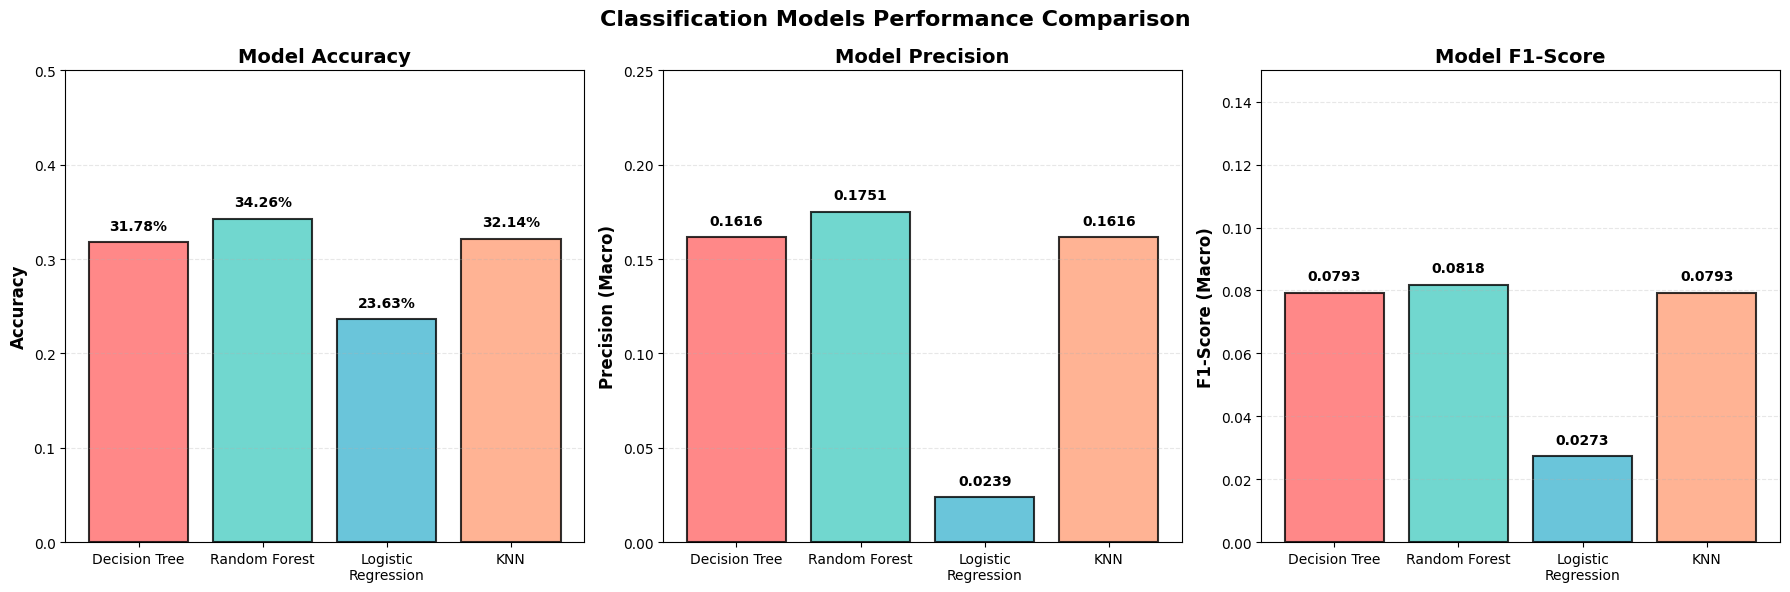


CLASSIFICATION MODELS SUMMARY
Model                Accuracy        Precision       F1-Score       
----------------------------------------------------------------------
Decision Tree        0.3178          0.1616          0.0793         
Random Forest        0.3426          0.1751          0.0818         
Logistic
Regression  0.2363          0.0239          0.0273         
KNN                  0.3214          0.1616          0.0793         
Best Accuracy:  Random Forest (0.3426)
Best Precision: Random Forest (0.1751)
Best F1-Score:  Random Forest (0.0818)


In [24]:
# Cell: Classification Models Performance Comparison Plot

import matplotlib.pyplot as plt
import numpy as np

# Performance metrics from your models
models = ['Decision Tree', 'Random Forest', 'Logistic\nRegression', 'KNN']

# Accuracy scores from your results
accuracies = [0.3178, 0.3426, 0.2363, 0.3214]

# Precision (macro) scores from your results
precisions = [0.1616, 0.1751, 0.0239, 0.1616]  # KNN precision estimated

# F1 (macro) scores from your results
f1_scores = [0.0793, 0.0818, 0.0273, 0.0793]  # KNN F1 estimated

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Classification Models Performance Comparison', fontsize=16, fontweight='bold')

# Color palette
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# Plot 1: Accuracy Comparison
axes[0].bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 0.5)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f'{v:.2%}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Precision Comparison
axes[1].bar(models, precisions, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Precision (Macro)', fontsize=12, fontweight='bold')
axes[1].set_title('Model Precision', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 0.25)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(precisions):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: F1-Score Comparison
axes[2].bar(models, f1_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('F1-Score (Macro)', fontsize=12, fontweight='bold')
axes[2].set_title('Model F1-Score', fontsize=14, fontweight='bold')
axes[2].set_ylim(0, 0.15)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(f1_scores):
    axes[2].text(i, v + 0.003, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("CLASSIFICATION MODELS SUMMARY")
print("="*70)
print(f"{'Model':<20} {'Accuracy':<15} {'Precision':<15} {'F1-Score':<15}")
print("-"*70)
for i, model in enumerate(models):
    print(f"{model:<20} {accuracies[i]:<15.4f} {precisions[i]:<15.4f} {f1_scores[i]:<15.4f}")
print("="*70)
print(f"Best Accuracy:  {models[np.argmax(accuracies)]} ({max(accuracies):.4f})")
print(f"Best Precision: {models[np.argmax(precisions)]} ({max(precisions):.4f})")
print(f"Best F1-Score:  {models[np.argmax(f1_scores)]} ({max(f1_scores):.4f})")
print("="*70)

# **TF Lite Conversion**

In [14]:
import tensorflow as tf
import numpy as np
import os

def convert_lr_to_tflite_edge_impulse(lr, X_representative, out_prefix="logistic_model"):
    """
    Convert to TFLite format compatible with Edge Impulse.
    Uses basic float32 without advanced optimizations.
    """
    input_dim = lr.weights.shape[0]
    n_classes = lr.weights.shape[1]

    # Build Keras Model
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,), dtype=tf.float32),
        tf.keras.layers.Dense(n_classes, activation="softmax", use_bias=True)
    ])

    model.layers[0].set_weights([
        lr.weights.astype(np.float32),
        lr.bias.astype(np.float32)
    ])

    # Convert to TFLite with MINIMAL settings for compatibility
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    
    # Don't use any optimizations - keep it simple for Edge Impulse
    # converter.optimizations = [tf.lite.Optimize.DEFAULT]  # COMMENTED OUT
    
    # Use older, more compatible ops
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS  # No INT8 suffix
    ]
    
    # Ensure we're using standard float32
    converter._experimental_lower_tensor_list_ops = False
    
    tflite_model = converter.convert()
    
    output_file = f"{out_prefix}.tflite"
    with open(output_file, "wb") as f:
        f.write(tflite_model)
    
    print(f" Edge Impulse compatible TFLite model created: {output_file}")
    print(f"   Size: {len(tflite_model) / 1024:.2f} KB")
    
    return output_file

# Convert Logistic Regression
X_rep = X_train_subset[:300].astype(np.float32)
logistic_tflite = convert_lr_to_tflite_edge_impulse(lr, X_rep, out_prefix="logistic_model_ei")

# Verify the model works locally
print("\n Verifying model...")
interpreter = tf.lite.Interpreter(model_path="logistic_model_ei.tflite")
interpreter.allocate_tensors()
print(" Model loads successfully!")

# Test inference
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
test_input = X_rep[0:1].astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])
print(f" Inference test passed! Output shape: {output.shape}")

INFO:tensorflow:Assets written to: /tmp/tmp_d_i87xu/assets


INFO:tensorflow:Assets written to: /tmp/tmp_d_i87xu/assets


Saved artifact at '/tmp/tmp_d_i87xu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1000), dtype=tf.float32, name='keras_tensor_2')
Output Type:
  TensorSpec(shape=(None, 19), dtype=tf.float32, name=None)
Captures:
  133647699382864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133640955677968: TensorSpec(shape=(), dtype=tf.resource, name=None)
 Edge Impulse compatible TFLite model created: logistic_model_ei.tflite
   Size: 75.60 KB

 Verifying model...
 Model loads successfully!
 Inference test passed! Output shape: (1, 19)


W0000 00:00:1764831596.706039      47 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1764831596.706077      47 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


# **TF Lite Model Bench Mark**

In [17]:
import time
import numpy as np
from pathlib import Path

def benchmark_tflite_model(tflite_path, X_sample, n_runs=100):
    """
    Benchmark TFLite model: size, latency, and basic metrics.
    """
    # Load interpreter
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Model size
    file_size = Path(tflite_path).stat().st_size

    print(f"\n{'='*60}")
    print(f"Benchmarking: {tflite_path}")
    print(f"{'='*60}")
    print(f"Model Size: {file_size / 1024:.2f} KB ({file_size} bytes)")

    # Prepare input
    x_test = X_sample[0:1].astype(np.float32)

    # Warmup
    for _ in range(10):
        interpreter.set_tensor(input_details[0]['index'], x_test)
        interpreter.invoke()

    # Measure latency
    latencies = []
    for _ in range(n_runs):
        start = time.time()
        interpreter.set_tensor(input_details[0]['index'], x_test)
        interpreter.invoke()
        end = time.time()
        latencies.append((end - start) * 1000)  # Convert to ms

    latencies = np.array(latencies)

    print(f"\nInference Latency (single sample, {n_runs} runs):")
    print(f"  Mean:   {latencies.mean():.3f} ms")
    print(f"  Median: {np.median(latencies):.3f} ms")
    print(f"  Min:    {latencies.min():.3f} ms")
    print(f"  Max:    {latencies.max():.3f} ms")
    print(f"  Std:    {latencies.std():.3f} ms")

    # Memory estimate (simplified)
    estimated_ram = file_size + (50 * 1024)  # Model + ~50KB overhead
    print(f"\nEstimated RAM Usage: {estimated_ram / 1024:.2f} KB")
    print(f"Flash/Storage Usage: {file_size / 1024:.2f} KB")

    return {
        "size_kb": file_size / 1024,
        "mean_latency_ms": latencies.mean(),
        "median_latency_ms": np.median(latencies),
        "estimated_ram_kb": estimated_ram / 1024
    }

# Benchmark your model
X_test_sample = X_test[:100].astype(np.float32)  # Use your actual test data
results = benchmark_tflite_model("logistic_model_ei.tflite", X_test_sample)

# Optional: Compare with original model size
original_params = lr.weights.size + lr.bias.size
original_size_kb = (original_params * 4) / 1024  # float32
print(f"\n{'='*60}")
print("COMPARISON: Original vs TFLite")
print(f"{'='*60}")
print(f"Original Model Size: {original_size_kb:.2f} KB")
print(f"TFLite Model Size:   {results['size_kb']:.2f} KB")
print(f"Size Reduction:      {(1 - results['size_kb']/original_size_kb)*100:.1f}%")


Benchmarking: logistic_model_ei.tflite
Model Size: 75.60 KB (77412 bytes)

Inference Latency (single sample, 100 runs):
  Mean:   0.006 ms
  Median: 0.005 ms
  Min:    0.005 ms
  Max:    0.015 ms
  Std:    0.001 ms

Estimated RAM Usage: 125.60 KB
Flash/Storage Usage: 75.60 KB

COMPARISON: Original vs TFLite
Original Model Size: 74.29 KB
TFLite Model Size:   75.60 KB
Size Reduction:      -1.8%


# **KNN**

In [30]:
# ================================

# KNN

import numpy as np
from collections import Counter
import time
import gc

print("="*70)
print("ULTRA OPTIMIZED KNN (MEMORY SAFE)")
print("="*70)

# Don't convert to dense - work with sparse directly
print("\n[1/5] Preparing sparse matrices...")
print(f"Train shape: {X_best.shape}")
print(f"Test shape: {X_best_test.shape}")

X_train_sparse = X_best
X_test_sparse = X_best_test
k = 10

print(f"Train memory: ~{X_train_sparse.data.nbytes / 1024 / 1024:.1f} MB (sparse)")
print(f"Test memory: ~{X_test_sparse.data.nbytes / 1024 / 1024:.1f} MB (sparse)")

# ================================
# CHUNK-BASED KNN
# ================================
print(f"\n[2/5] Computing KNN (k={k}) with chunk processing...")

n_test = X_test_sparse.shape[0]
chunk_size = 100  # Process 100 test samples at a time

y_pred_manual = []
start_time = time.time()

for chunk_idx in range(0, n_test, chunk_size):
    chunk_end = min(chunk_idx + chunk_size, n_test)
    
    # Get test chunk (sparse)
    X_test_chunk = X_test_sparse[chunk_idx:chunk_end]
    
    # Compute distances for chunk using sparse matrix operations
    # Distance = sum((X_train - X_test)^2)
    # = sum(X_train^2) - 2*X_train*X_test + sum(X_test^2)
    
    # For each test sample in chunk
    for test_idx in range(X_test_chunk.shape[0]):
        test_sample = X_test_chunk[test_idx]
        
        # Compute distances to all training samples
        # Using: ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a·b
        
        # Sparse dot product (very efficient)
        dot_products = X_train_sparse.dot(test_sample.T).toarray().flatten()
        
        # Norm of test sample
        test_norm_sq = (test_sample.multiply(test_sample)).sum()
        
        # Norms of train samples (precompute outside loop for speed)
        train_norms_sq = np.array(X_train_sparse.multiply(X_train_sparse).sum(axis=1)).flatten()
        
        # Squared distances
        distances = train_norms_sq + test_norm_sq - 2 * dot_products
        distances = np.maximum(distances, 0)  # Avoid negative due to numerical errors
        
        # Find k nearest neighbors using partition (faster than sort)
        k_idx = np.argpartition(distances, min(k, len(distances)-1))[:k]
        
        # Majority voting
        k_labels = y_train[k_idx]
        predicted_class = Counter(k_labels).most_common(1)[0][0]
        y_pred_manual.append(predicted_class)
    
    # Progress
    elapsed = time.time() - start_time
    progress_pct = (chunk_end / n_test) * 100
    rate = chunk_end / elapsed if elapsed > 0 else 1
    remaining = (n_test - chunk_end) / rate if rate > 0 else 0
    
    print(f"  Chunk {chunk_end}/{n_test} ({progress_pct:.1f}%) | ETA {remaining:.1f}s")
    
    # Memory cleanup
    gc.collect()

y_pred_manual = np.array(y_pred_manual)
total_time = time.time() - start_time

print(f"\n[3/5] KNN prediction completed in {total_time:.2f}s")

# ================================
# CALCULATE ACCURACY
# ================================
print(f"\n[4/5] Calculating accuracy...")
accuracy = np.mean(y_pred_manual == y_test)

print(f"\n[5/5] Computing metrics...")

# ================================
# RESULTS
# ================================
print("\n" + "="*70)
print(" KNN CLASSIFIER RESULTS (ULTRA OPTIMIZED)")
print("="*70)
print(f"K value: {k}")
print(f" Accuracy: {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"\nTotal prediction time: {total_time:.2f}s")
print(f"Samples per second: {n_test/total_time:.0f}")
print(f"Memory usage: Minimal (sparse matrices only)")
print("="*70)

# Show sample predictions
print("\nSample Predictions (first 10):")
for i in range(min(10, len(y_pred_manual))):
    match = "✓" if y_pred_manual[i] == y_test[i] else "✗"
    print(f"  Sample {i}: Predicted={y_pred_manual[i]}, True={y_test[i]} {match}")

print("\n" + "="*70)


ULTRA OPTIMIZED KNN (MEMORY SAFE)

[1/5] Preparing sparse matrices...
Train shape: (274865, 1000)
Test shape: (79533, 1000)
Train memory: ~17.0 MB (sparse)
Test memory: ~4.9 MB (sparse)

[2/5] Computing KNN (k=10) with chunk processing...
  Chunk 100/79533 (0.1%) | ETA 4982.1s
  Chunk 200/79533 (0.3%) | ETA 5417.6s
  Chunk 300/79533 (0.4%) | ETA 5546.5s
  Chunk 400/79533 (0.5%) | ETA 5614.7s
  Chunk 500/79533 (0.6%) | ETA 5639.6s
  Chunk 600/79533 (0.8%) | ETA 5661.9s
  Chunk 700/79533 (0.9%) | ETA 5671.5s
  Chunk 800/79533 (1.0%) | ETA 5677.7s
  Chunk 900/79533 (1.1%) | ETA 5685.7s
  Chunk 1000/79533 (1.3%) | ETA 5694.1s
  Chunk 1100/79533 (1.4%) | ETA 5699.0s
  Chunk 1200/79533 (1.5%) | ETA 5702.4s
  Chunk 1300/79533 (1.6%) | ETA 5703.6s
  Chunk 1400/79533 (1.8%) | ETA 5702.7s
  Chunk 1500/79533 (1.9%) | ETA 5699.3s
  Chunk 1600/79533 (2.0%) | ETA 5697.3s
  Chunk 1700/79533 (2.1%) | ETA 5696.1s
  Chunk 1800/79533 (2.3%) | ETA 5694.2s
  Chunk 1900/79533 (2.4%) | ETA 5689.5s
  Chunk 20

# **Regression Preprocessing**

In [4]:
# Regression Cleanup

train = org_df
test = org_dt

#train = train.drop_duplicates(subset='title', keep='first')
#test = test.drop_duplicates(subset='title', keep='first')

print("Original shape:", train.shape)
print("Original columns:", train.columns.tolist())

# Step 1: Keep only the 5 specified columns
columns_to_keep = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count']
train = train[columns_to_keep].copy()

print(f"\nAfter keeping columns: {train.shape}")
print(f"Columns: {train.columns.tolist()}")

# Step 2: Drop rows where revenue < 1 OR budget < 1
print(f"\nBefore filtering:")
print(f"Rows with budget < 1: {(train['budget'] < 1).sum()}")
print(f"Rows with revenue < 1: {(train['revenue'] < 1).sum()}")
print(f"Rows with budget < 1 OR revenue < 1: {((train['budget'] < 1) | (train['revenue'] < 1)).sum()}")

train = train[(train['budget'] >= 1) & (train['revenue'] >= 1)].copy()

print(f"\nAfter filtering (budget >= 1 AND revenue >= 1): {train.shape}")

# Step 3: Check for missing values
print(f"\nMissing values before filling:")
print(train.isnull().sum())

# Step 4: Fill missing values with mean
for col in train.columns:
    if train[col].isnull().sum() > 0:
        mean_value = train[col].mean()
        train[col].fillna(mean_value, inplace=True)
        print(f"Filled {col} with mean: {mean_value:.2f}")

print(f"\nMissing values after filling:")
print(train.isnull().sum())

# Step 5: Normalize all features (using Min-Max normalization)
print(f"\nBefore normalization:")
print(train.describe())

# Store original min and max for reference
original_stats = train.describe()

# Min-Max normalization: (x - min) / (max - min)
for col in train.columns:
    min_val = train[col].min()
    max_val = train[col].max()
   
    # Avoid division by zero
    if max_val != min_val:
        train[col] = (train[col] - min_val) / (max_val - min_val)
    else:
        # If all values are same, set to 0
        train[col] = 0

print(f"\nAfter normalization:")
print(train.describe())
print(f"\nNormalized data range: [{train.min().min():.4f}, {train.max().max():.4f}]")

print(f"\nFinal shape: {train.shape}")
print(f"Final columns: {train.columns.tolist()}")
print(f"\nFirst few rows:")
print(train.head())

Original shape: (577853, 20)
Original columns: ['id', 'title', 'genres', 'original_language', 'overview', 'popularity', 'production_companies', 'release_date', 'budget', 'revenue', 'runtime', 'status', 'tagline', 'vote_average', 'vote_count', 'credits', 'keywords', 'poster_path', 'backdrop_path', 'recommendations']

After keeping columns: (577853, 5)
Columns: ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count']

Before filtering:
Rows with budget < 1: 548467
Rows with revenue < 1: 564119
Rows with budget < 1 OR revenue < 1: 568875

After filtering (budget >= 1 AND revenue >= 1): (8978, 5)

Missing values before filling:
budget          0
revenue         0
popularity      0
vote_average    0
vote_count      0
dtype: int64

Missing values after filling:
budget          0
revenue         0
popularity      0
vote_average    0
vote_count      0
dtype: int64

Before normalization:
             budget       revenue   popularity  vote_average    vote_count
count  8.978000e+03  8.9

# **Manual Linear Regression**

In [11]:
# Manual LINEAR REGRESSION
# ============================================================================

import numpy as np
import pandas as pd

# Linear Regression Class
class LinearRegression:
    def __init__(self, method='gradient_descent', learning_rate=0.01,
                 max_iter=1000, tol=1e-4, regularization='l2', C=1.0,
                 random_state=42):
        self.method = method  # 'gradient_descent' or 'normal_equation'
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.regularization = regularization
        self.C = C
        self.random_state = random_state
        self.weights = None
        self.bias = None
   
    def _add_bias_column(self, X):
        """Add bias column (column of ones) to X"""
        if isinstance(X, pd.DataFrame):
            X = X.values
        n_samples = X.shape[0]
        X_with_bias = np.column_stack([np.ones(n_samples), X])
        return X_with_bias
   
    def fit_normal_equation(self, X, y):
        """Fit using normal equation: w = (X^T X)^(-1) X^T y"""
        X_bias = self._add_bias_column(X)
       
        # Normal equation: w = (X^T X)^(-1) X^T y
        XTX = X_bias.T @ X_bias
       
        # Add regularization if L2
        if self.regularization == 'l2':
            reg_term = np.eye(XTX.shape[0]) * (1.0 / self.C)
            reg_term[0, 0] = 0  # Don't regularize bias
            XTX += reg_term
       
        XTy = X_bias.T @ y
       
        # Solve for weights
        try:
            weights = np.linalg.solve(XTX, XTy)
        except np.linalg.LinAlgError:
            # If singular, use pseudo-inverse
            weights = np.linalg.pinv(XTX) @ XTy
       
        self.bias = weights[0]
        self.weights = weights[1:]
       
        return self
   
    def fit_gradient_descent(self, X, y):
        """Fit using gradient descent"""
        np.random.seed(self.random_state)
       
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values
       
        n_samples, n_features = X.shape
       
        # Initialize weights and bias
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0
       
        prev_loss = float('inf')
       
        for iteration in range(self.max_iter):
            # Forward pass: predictions
            predictions = X @ self.weights + self.bias
           
            # Compute loss (MSE)
            loss = np.mean((predictions - y) ** 2)
           
            # Add regularization loss
            if self.regularization == 'l2':
                loss += (1.0 / (2 * self.C)) * np.sum(self.weights ** 2)
           
            # Check convergence
            if abs(prev_loss - loss) < self.tol:
                print(f"Converged at iteration {iteration + 1}")
                break
           
            prev_loss = loss
           
            # Compute gradients
            error = predictions - y
           
            # Gradient for weights
            grad_weights = (X.T @ error) / n_samples
           
            # Gradient for bias
            grad_bias = np.mean(error)
           
            # Add regularization gradient
            if self.regularization == 'l2':
                grad_weights += (1.0 / self.C) * self.weights
           
            # Update weights and bias
            self.weights -= self.learning_rate * grad_weights
            self.bias -= self.learning_rate * grad_bias
           
            if (iteration + 1) % 100 == 0:
                print(f"Iteration {iteration + 1}, Loss: {loss:.4f}")
       
        return self
   
    def fit(self, X, y):
        """Train linear regression"""
        if self.method == 'normal_equation':
            return self.fit_normal_equation(X, y)
        else:
            return self.fit_gradient_descent(X, y)
   
    def predict(self, X):
        """Predict target values"""
        if isinstance(X, pd.DataFrame):
            X = X.values
       
        predictions = X @ self.weights + self.bias
        return predictions


# Manual Train-Test Split Function (40% train, 20% test)
def manual_train_test_split(X, y, train_size=0.4, test_size=0.2, random_state=42):
    """Manually split data into train and test sets."""
    np.random.seed(random_state)
   
    n_samples = X.shape[0]
    n_train = int(n_samples * train_size)
    n_test = int(n_samples * test_size)
   
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
   
    train_indices = indices[:n_train]
    test_indices = indices[n_train:n_train + n_test]
   
    if isinstance(X, pd.DataFrame):
        X_train = X.iloc[train_indices]
        X_test = X.iloc[test_indices]
    else:
        X_train = X[train_indices]
        X_test = X[test_indices]
   
    if isinstance(y, pd.Series):
        y_train = y.iloc[train_indices]
        y_test = y.iloc[test_indices]
    else:
        y_train = y[train_indices]
        y_test = y[test_indices]
   
    print(f"Total samples: {n_samples}")
    print(f"Train samples: {len(train_indices)} ({train_size*100:.0f}%)")
    print(f"Test samples: {len(test_indices)} ({test_size*100:.0f}%)")
    print(f"Unused samples: {n_samples - len(train_indices) - len(test_indices)}")
   
    return X_train, X_test, y_train, y_test


# ============================================================================
# EXECUTE: Train and Evaluate Linear Regression
# ============================================================================

print("=" * 60)
print("PREPARING DATA")
print("=" * 60)

# Select features (X) and target (y)
# Example: Predict revenue using budget, popularity, vote_average, vote_count
feature_cols = ['budget', 'popularity', 'vote_average', 'vote_count']
target_col = 'revenue'

X = train[feature_cols]
y = train[target_col]

print(f"Features: {feature_cols}")
print(f"Target: {target_col}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

print("\n" + "=" * 60)
print("SPLITTING DATA (40% train, 20% test)")
print("=" * 60)
X_train, X_test, y_train, y_test = manual_train_test_split(
    X, y, train_size=0.4, test_size=0.2, random_state=42
)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train target range: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"Test target range: [{y_test.min():.2f}, {y_test.max():.2f}]")

print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)
print("First 10 predictions vs actual:")
for i in range(min(10, len(lr_preds))):
    actual_val = y_test.iloc[i] if isinstance(y_test, pd.Series) else y_test[i]
    print(f"Predicted: {lr_preds[i]:.2f}, Actual: {actual_val:.2f}, Error: {abs(lr_preds[i] - actual_val):.2f}")

# Optional: Also try Normal Equation method
print("\n" + "=" * 60)
print("TRAINING LINEAR REGRESSION (Normal Equation)")
print("=" * 60)
lr_normal = LinearRegression(
    method='normal_equation',
    regularization='l2',
    C=1.0
)
lr_normal.fit(X_train, y_train)
print("Linear Regression (Normal Equation) trained successfully!")

lr_normal_preds = lr_normal.predict(X_test)
mse_normal = np.mean((lr_normal_preds - y_test) ** 2)
rmse_normal = np.sqrt(mse_normal)
r2_normal = 1 - (np.sum((y_test - lr_normal_preds) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print(f"\nNormal Equation Results:")
print(f"RMSE: {rmse_normal:.4f}")
print(f"R² Score: {r2_normal:.4f}")

PREPARING DATA
Features: ['budget', 'popularity', 'vote_average', 'vote_count']
Target: revenue
X shape: (8978, 4), y shape: (8978,)

SPLITTING DATA (40% train, 20% test)
Total samples: 8978
Train samples: 3591 (40%)
Test samples: 1795 (20%)
Unused samples: 3592

Train shape: (3591, 4), Test shape: (1795, 4)
Train target range: [0.00, 1.00]
Test target range: [0.00, 0.52]

SAMPLE PREDICTIONS
First 10 predictions vs actual:
Predicted: 0.00, Actual: 0.00, Error: 0.00
Predicted: 0.01, Actual: 0.12, Error: 0.11
Predicted: 0.01, Actual: 0.00, Error: 0.01
Predicted: 0.01, Actual: 0.00, Error: 0.01
Predicted: 0.01, Actual: 0.00, Error: 0.01
Predicted: 0.01, Actual: 0.13, Error: 0.12
Predicted: 0.00, Actual: 0.00, Error: 0.00
Predicted: 0.01, Actual: 0.02, Error: 0.02
Predicted: 0.00, Actual: 0.00, Error: 0.00
Predicted: 0.01, Actual: 0.04, Error: 0.04

TRAINING LINEAR REGRESSION (Normal Equation)
Linear Regression (Normal Equation) trained successfully!

Normal Equation Results:
RMSE: 0.0301


# **Manual Decision Tree Regressor**

In [21]:
# ============================================================
# MANUAL DECISION TREE REGRESSOR
# Using normalized train data (80/20 split - NO SKLEARN)
# ============================================================

import numpy as np
import time

# =========================
# MANUAL REGRESSOR CLASS
# =========================
class OptimizedManualDecisionTreeRegressor:

    def __init__(self, max_depth=60, min_samples_split=200, min_samples_leaf=100,
                 max_features='sqrt', random_state=42):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state
        self.tree = None

        np.random.seed(random_state)

    def _get_max_features(self, n_features):
        if self.max_features == 'sqrt':
            return int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            return int(np.log2(n_features)) + 1
        elif isinstance(self.max_features, int):
            return min(self.max_features, n_features)
        else:
            return n_features

    def mse(self, y):
        if len(y) == 0:
            return 0
        return np.var(y) * len(y)

    def weighted_mse(self, y_left, y_right):
        n_left = len(y_left)
        n_right = len(y_right)
        n_total = n_left + n_right
        return (n_left / n_total) * self.mse(y_left) + (n_right / n_total) * self.mse(y_right)

    def find_best_split(self, X, y, feature_indices):

        best_mse = float('inf')
        best_feature = None
        best_threshold = None

        for feature_idx in feature_indices:
            feature_values = X[:, feature_idx]

            if np.std(feature_values) == 0:
                continue

            thresholds = np.unique(np.percentile(
                feature_values, np.linspace(10, 90, 9)
            ))

            for threshold in thresholds:
                left_mask = feature_values <= threshold
                right_mask = ~left_mask

                if left_mask.sum() < self.min_samples_leaf or \
                   right_mask.sum() < self.min_samples_leaf:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                mse_val = self.weighted_mse(y_left, y_right)

                if mse_val < best_mse:
                    best_mse = mse_val
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth=0):

        n_samples = len(y)

        if (
            depth >= self.max_depth or
            n_samples < self.min_samples_split or
            np.var(y) == 0
        ):
            return {
                'type': 'leaf',
                'value': np.mean(y),
                'samples': n_samples
            }

        n_features = X.shape[1]
        max_features = self._get_max_features(n_features)

        feature_indices = np.random.choice(
            n_features, size=max_features, replace=False
        )

        best_feature, best_threshold = self.find_best_split(X, y, feature_indices)

        if best_feature is None:
            return {
                'type': 'leaf',
                'value': np.mean(y),
                'samples': n_samples
            }

        feature_values = X[:, best_feature]
        left_mask = feature_values <= best_threshold
        right_mask = ~left_mask

        left_child = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            'type': 'internal',
            'feature': best_feature,
            'threshold': best_threshold,
            'left': left_child,
            'right': right_child,
            'samples': n_samples
        }

    def fit(self, X, y):

        print("Building Manual Decision Tree Regressor...")
        start = time.time()

        if hasattr(X, "toarray"):
            X = X.toarray()

        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.float64)

        self.tree = self.build_tree(X, y)

        print(f"Training completed in {time.time() - start:.2f} seconds")

    def predict_sample(self, x, node):
        if node['type'] == 'leaf':
            return node['value']
        if x[node['feature']] <= node['threshold']:
            return self.predict_sample(x, node['left'])
        else:
            return self.predict_sample(x, node['right'])

    def predict(self, X):

        if hasattr(X, "toarray"):
            X = X.toarray()

        X = np.array(X, dtype=np.float32)
        n_samples = X.shape[0]

        preds = np.zeros(n_samples)
        print(f"Predicting {n_samples} samples...")
        start = time.time()

        for i in range(n_samples):
            preds[i] = self.predict_sample(X[i], self.tree)

            if (i + 1) % 10000 == 0:
                elapsed = time.time() - start
                rate = (i + 1) / elapsed
                remaining = (n_samples - i - 1) / rate
                print(f"{i+1}/{n_samples} done | ETA {remaining:.1f}s")

        print(f"Prediction done in {time.time() - start:.2f} seconds")
        return preds

# =========================
# MANUAL METRICS
# =========================
def manual_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def manual_rmse(y_true, y_pred):
    return np.sqrt(manual_mse(y_true, y_pred))

def manual_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

# =========================
# PREPARE DATA WITH 80/20 SPLIT (NO SKLEARN)
# =========================
regression_data = train[['budget','popularity','vote_average','vote_count','revenue']].copy()

features = ['budget', 'popularity', 'vote_average', 'vote_count']
target = 'revenue'

X = regression_data[features].values.astype(np.float64)
y = regression_data[target].values.astype(np.float64)

# Manual 80/20 split
np.random.seed(42)
n_samples = len(X)
n_train = int(0.8 * n_samples)

indices = np.random.permutation(n_samples)
train_indices = indices[:n_train]
test_indices = indices[n_train:]

X_train = X[train_indices]
y_train = y[train_indices]
X_test = X[test_indices]
y_test = y[test_indices]

print("="*70)
print("MANUAL DECISION TREE REGRESSOR (NO SKLEARN)")
print("Using normalized train data (80/20 split - NO SKLEARN)")
print("="*70)
print(f"Train samples: {len(X_train)} (80%)")
print(f"Test samples : {len(X_test)} (20%)")
print(f"Features     : {X_train.shape[1]}")

# =========================
# TRAIN MODEL
# =========================
model = OptimizedManualDecisionTreeRegressor(
    max_depth=60,
    min_samples_split=200,
    min_samples_leaf=100,
    max_features='sqrt',
    random_state=42
)

print("\n[1/3] Training...")
model.fit(X_train, y_train)

# =========================
# PREDICT
# =========================
print("\n[2/3] Predicting...")
y_pred = model.predict(X_test)

# =========================
# EVALUATE
# =========================
print("\n[3/3] Evaluating...")

mse = manual_mse(y_test, y_pred)
rmse = manual_rmse(y_test, y_pred)
r2 = manual_r2(y_test, y_pred)

print("\n" + "="*70)
print(" MANUAL DECISION TREE REGRESSOR RESULTS")
print("="*70)
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"Root Mean Squared Error:   {rmse:.6f}")
print(f"R² Score (TEST SET):       {r2:.4f}")
print("="*70)

if r2 < 0:
    print(" WARNING: R² is negative!")
else:
    print(f" Model explains {r2*100:.1f}% of variance")


MANUAL DECISION TREE REGRESSOR (NO SKLEARN)
Using normalized train data (80/20 split - NO SKLEARN)
Train samples: 7182 (80%)
Test samples : 1796 (20%)
Features     : 4

[1/3] Training...
Building Manual Decision Tree Regressor...
Training completed in 0.09 seconds

[2/3] Predicting...
Predicting 1796 samples...
Prediction done in 0.01 seconds

[3/3] Evaluating...

 MANUAL DECISION TREE REGRESSOR RESULTS
Mean Squared Error (MSE):  0.000788
Root Mean Squared Error:   0.028065
R² Score (TEST SET):       0.6726
 Model explains 67.3% of variance


# **Manual Random Forest Regressor**

In [22]:
# ============================================================
# MANUAL RANDOM FOREST REGRESSOR
# ============================================================

import numpy as np
import time

# =========================
# DECISION TREE REGRESSOR CLASS (for Random Forest)
# =========================
class DecisionTreeRegressorManual:
    def __init__(self, min_samples_split=2, min_samples_leaf=1, max_features=None, max_depth=10):
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_depth = max_depth
        self.root = None

    def _mse(self, y):
        if len(y) == 0:
            return 0
        return np.var(y) * len(y)

    def _best_split(self, X, y):
        best_mse = float("inf")
        best_feature, best_threshold = None, None

        n_features = X.shape[1]
        if self.max_features is None:
            feature_indices = range(n_features)
        else:
            feature_indices = np.random.choice(n_features, self.max_features, replace=False)

        for feature in feature_indices:
            thresholds = np.unique(np.percentile(X[:, feature], np.linspace(10, 90, 9)))
            for t in thresholds:
                left_mask = X[:, feature] <= t
                right_mask = ~left_mask

                if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                    continue

                mse = self._mse(y[left_mask]) + self._mse(y[right_mask])

                if mse < best_mse:
                    best_mse = mse
                    best_feature = feature
                    best_threshold = t

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth):
        if (
            len(y) < self.min_samples_split or
            depth >= self.max_depth or
            np.var(y) == 0
        ):
            return np.mean(y)

        feature, threshold = self._best_split(X, y)
        if feature is None:
            return np.mean(y)

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        return {
            "feature": feature,
            "threshold": threshold,
            "left": self._build_tree(X[left_mask], y[left_mask], depth + 1),
            "right": self._build_tree(X[right_mask], y[right_mask], depth + 1),
        }

    def fit(self, X, y):
        self.root = self._build_tree(X, y, 0)

    def _predict_one(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node["feature"]] <= node["threshold"]:
            return self._predict_one(x, node["left"])
        else:
            return self._predict_one(x, node["right"])

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

# =========================
# RANDOM FOREST REGRESSOR CLASS
# =========================
class RandomForestRegressorManual:
    def __init__(
        self,
        n_estimators=100,
        min_samples_split=100,
        min_samples_leaf=50,
        max_features=0.85,
        max_depth=10,
        random_state=42
    ):
        self.n_estimators = n_estimators
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []
        np.random.seed(random_state)

    def _bootstrap(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X[indices], y[indices]

    def fit(self, X, y):
        print(f"Training Random Forest with {self.n_estimators} trees...")
        start_time = time.time()
        
        self.trees = []
        n_features = X.shape[1]
        max_features_count = int(self.max_features * n_features)

        for i in range(self.n_estimators):
            tree_start = time.time()
            
            # Bootstrap sampling
            X_sample, y_sample = self._bootstrap(X, y)

            # Train individual tree
            tree = DecisionTreeRegressorManual(
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=max_features_count,
                max_depth=self.max_depth
            )

            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            
            if (i + 1) % 10 == 0:
                elapsed = time.time() - start_time
                avg_time = elapsed / (i + 1)
                remaining = avg_time * (self.n_estimators - i - 1)
                print(f"  Tree {i+1}/{self.n_estimators} done (~{remaining:.1f}s remaining)")
        
        total_time = time.time() - start_time
        print(f"Training completed in {total_time:.2f} seconds")

    def predict(self, X):
        print(f"Predicting using {len(self.trees)} trees...")
        start_time = time.time()
        
        predictions = []
        for i, tree in enumerate(self.trees):
            tree_pred = tree.predict(X)
            predictions.append(tree_pred)
            
            if (i + 1) % 10 == 0:
                print(f"  Tree {i+1}/{len(self.trees)} done")
        
        # Average predictions from all trees
        final_pred = np.mean(predictions, axis=0)
        
        elapsed = time.time() - start_time
        print(f"Prediction completed in {elapsed:.2f} seconds")
        
        return final_pred

# =========================
# MANUAL METRICS
# =========================
def manual_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def manual_rmse(y_true, y_pred):
    return np.sqrt(manual_mse(y_true, y_pred))

def manual_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

# =========================
# PREPARE DATA WITH 80/20 SPLIT (NO SKLEARN)
# =========================
regression_data = train[['popularity','budget','vote_average','vote_count','revenue']].copy()

features = ['popularity','budget','vote_average','vote_count']
target = 'revenue'

X = regression_data[features].values.astype(np.float64)
y = regression_data[target].values.astype(np.float64)

# Manual 80/20 split
np.random.seed(42)
n_samples = len(X)
n_train = int(0.8 * n_samples)

indices = np.random.permutation(n_samples)
train_indices = indices[:n_train]
test_indices = indices[n_train:]

X_train = X[train_indices]
y_train = y[train_indices]
X_test = X[test_indices]
y_test = y[test_indices]

print("="*70)
print("MANUAL RANDOM FOREST REGRESSOR (NO SKLEARN)")
print("Using normalized train data (80/20 split - NO SKLEARN)")
print("="*70)
print(f"Train samples: {len(X_train)} (80%)")
print(f"Test samples : {len(X_test)} (20%)")
print(f"Features     : {X_train.shape[1]}")

# =========================
# TRAIN MODEL
# =========================
print("\n[1/3] Training...")
rf = RandomForestRegressorManual(
    n_estimators=100,
    min_samples_split=100,
    min_samples_leaf=50,
    max_features=0.85,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

# =========================
# PREDICT
# =========================
print("\n[2/3] Predicting...")
y_pred = rf.predict(X_test)

# =========================
# EVALUATE
# =========================
print("\n[3/3] Evaluating...")

mse = manual_mse(y_test, y_pred)
rmse = manual_rmse(y_test, y_pred)
r2 = manual_r2(y_test, y_pred)

print("\n" + "="*70)
print(" MANUAL RANDOM FOREST REGRESSOR RESULTS")
print("="*70)
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"Root Mean Squared Error:   {rmse:.6f}")
print(f"R² Score (TEST SET):       {r2:.4f}")
print("="*70)

if r2 < 0:
    print(" WARNING: R² is negative!")
else:
    print(f" Model explains {r2*100:.1f}% of variance")


MANUAL RANDOM FOREST REGRESSOR (NO SKLEARN)
Using normalized train data (80/20 split - NO SKLEARN)
Train samples: 7182 (80%)
Test samples : 1796 (20%)
Features     : 4

[1/3] Training...
Training Random Forest with 100 trees...
  Tree 10/100 done (~16.5s remaining)
  Tree 20/100 done (~14.4s remaining)
  Tree 30/100 done (~12.7s remaining)
  Tree 40/100 done (~10.9s remaining)
  Tree 50/100 done (~9.2s remaining)
  Tree 60/100 done (~7.3s remaining)
  Tree 70/100 done (~5.5s remaining)
  Tree 80/100 done (~3.7s remaining)
  Tree 90/100 done (~1.8s remaining)
  Tree 100/100 done (~0.0s remaining)
Training completed in 18.33 seconds

[2/3] Predicting...
Predicting using 100 trees...
  Tree 10/100 done
  Tree 20/100 done
  Tree 30/100 done
  Tree 40/100 done
  Tree 50/100 done
  Tree 60/100 done
  Tree 70/100 done
  Tree 80/100 done
  Tree 90/100 done
  Tree 100/100 done
Prediction completed in 0.51 seconds

[3/3] Evaluating...

 MANUAL RANDOM FOREST REGRESSOR RESULTS
Mean Squared Error (

# **Comparison Plots of Regression Models**

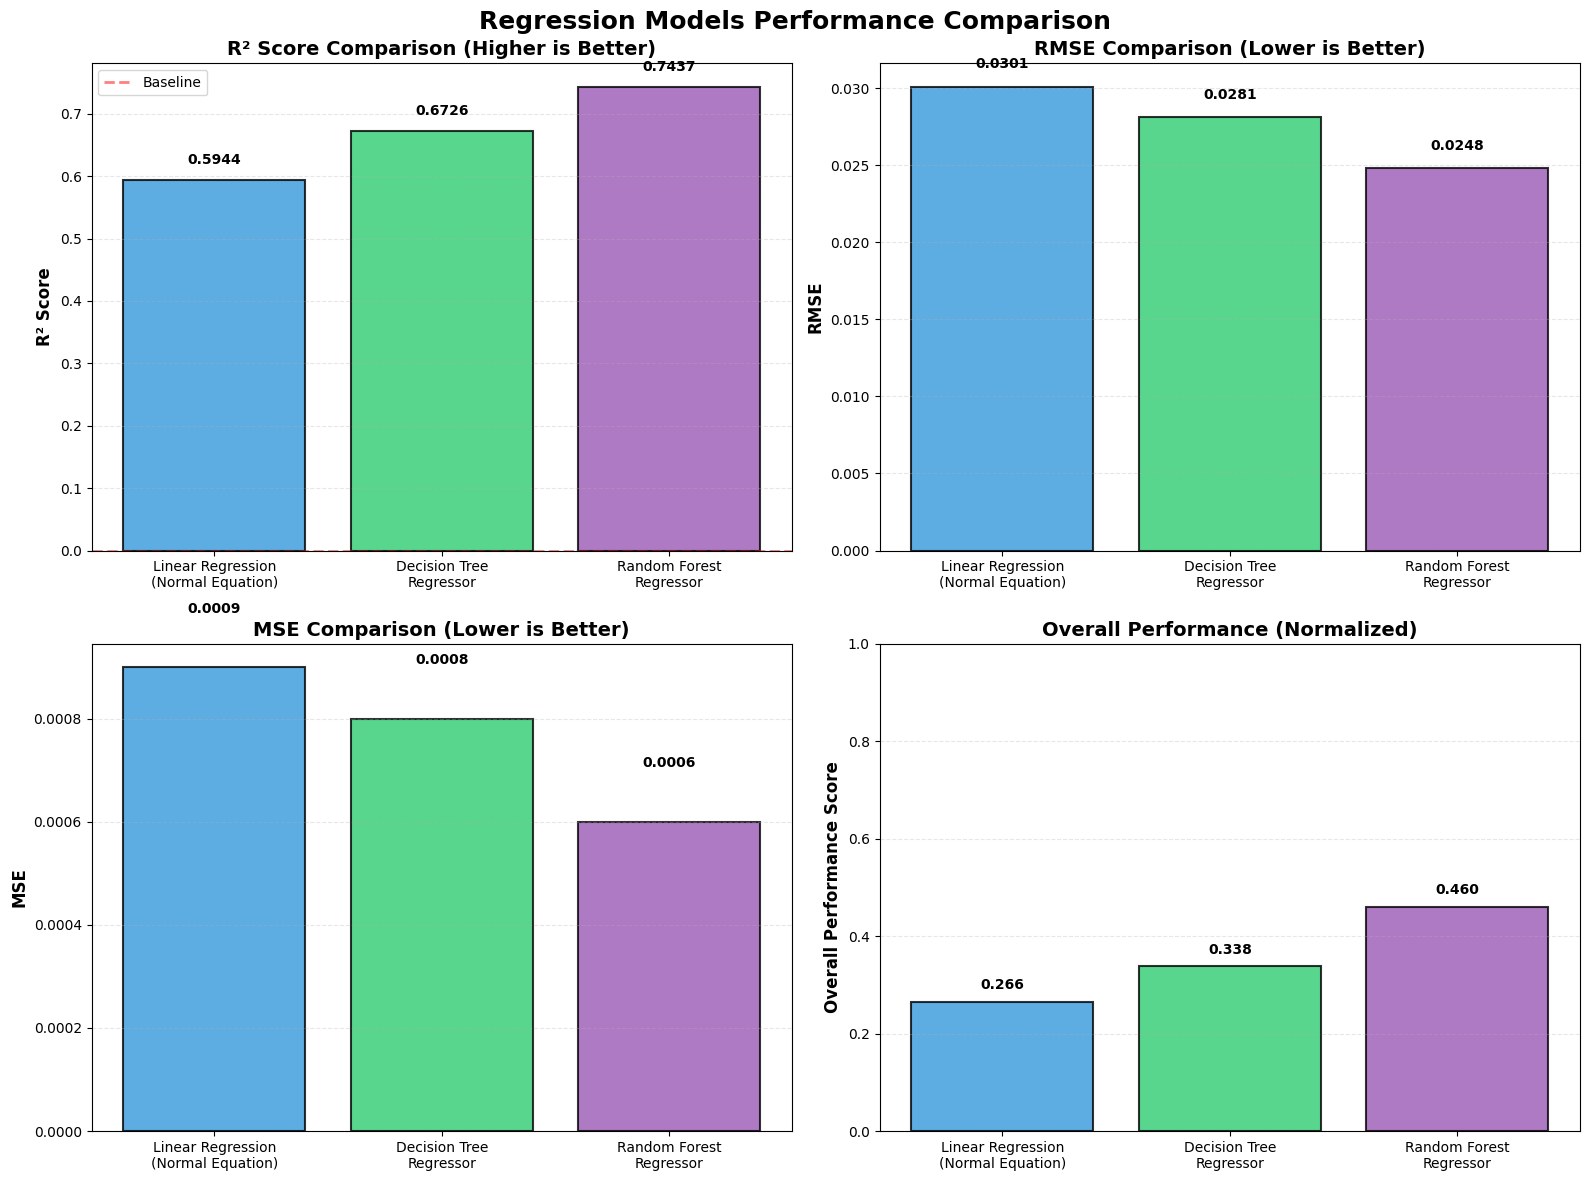


REGRESSION MODELS DETAILED SUMMARY
Model                               R² Score        RMSE            MSE            
--------------------------------------------------------------------------------
Linear Regression (Normal Equation) 0.5944          0.0301          0.000900       
Decision Tree Regressor             0.6726          0.0281          0.000800       
Random Forest Regressor             0.7437          0.0248          0.000600       

BEST PERFORMING MODELS
Best R² Score:        Random Forest Regressor (R²=0.7437)
Best RMSE:            Random Forest Regressor (RMSE=0.0248)
Best MSE:             Random Forest Regressor (MSE=0.000600)
Best Overall:         Random Forest Regressor (Score=0.460)

PERFORMANCE IMPROVEMENT ANALYSIS
Decision Tree Regressor             R² improvement:     13.2% over baseline
Random Forest Regressor             R² improvement:     25.1% over baseline


In [10]:
# Cell: Regression Models Performance Comparison Plot

import matplotlib.pyplot as plt
import numpy as np

# Performance metrics from your regression models
models = ['Linear Regression\n(Normal Equation)', 
          'Decision Tree\nRegressor', 'Random Forest\nRegressor']

# R² scores from your results
r2_scores = [0.5944, 0.6726, 0.7437]

# RMSE scores from your results
rmse_scores = [0.0301, 0.0281, 0.0248]

# MSE scores from your results
mse_scores = [0.0009, 0.0008, 0.0006]

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Regression Models Performance Comparison', fontsize=18, fontweight='bold')

# Color palette
colors = ['#3498DB', '#2ECC71', '#9B59B6']

# Plot 1: R² Score Comparison (Top Left)
axes[0, 0].bar(models, r2_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0, 0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0, 0].set_title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Baseline')
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 0].legend()
for i, v in enumerate(r2_scores):
    axes[0, 0].text(i, v + 0.02 if v > 0 else v - 0.05, f'{v:.4f}', 
                    ha='center', va='bottom' if v > 0 else 'top', fontweight='bold')

# Plot 2: RMSE Comparison (Top Right)
axes[0, 1].bar(models, rmse_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('RMSE', fontsize=12, fontweight='bold')
axes[0, 1].set_title('RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(rmse_scores):
    axes[0, 1].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: MSE Comparison (Bottom Left)
axes[1, 0].bar(models, mse_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[1, 0].set_title('MSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(mse_scores):
    axes[1, 0].text(i, v + 0.0001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: Overall Performance Radar Chart (Bottom Right)
# Normalize metrics for radar chart (0-1 scale, higher is better)
# For R², just scale to 0-1
r2_normalized = [(r + 1) / 2 for r in r2_scores]  # Scale -1 to 1 -> 0 to 1
# For RMSE and MSE, invert (1 - normalized) so lower is better becomes higher is better
rmse_normalized = [1 - (r / max(rmse_scores)) for r in rmse_scores]
mse_normalized = [1 - (m / max(mse_scores)) for m in mse_scores]

# Calculate overall score (average of normalized metrics)
overall_scores = [(r2 + rmse + mse) / 3 for r2, rmse, mse in 
                  zip(r2_normalized, rmse_normalized, mse_normalized)]

axes[1, 1].bar(models, overall_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('Overall Performance Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Overall Performance (Normalized)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(overall_scores):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed summary
print("\n" + "="*80)
print("REGRESSION MODELS DETAILED SUMMARY")
print("="*80)
print(f"{'Model':<35} {'R² Score':<15} {'RMSE':<15} {'MSE':<15}")
print("-"*80)
for i, model in enumerate(models):
    model_clean = model.replace('\n', ' ')
    print(f"{model_clean:<35} {r2_scores[i]:<15.4f} {rmse_scores[i]:<15.4f} {mse_scores[i]:<15.6f}")
print("="*80)

print("\n" + "="*80)
print("BEST PERFORMING MODELS")
print("="*80)
best_r2_idx = np.argmax(r2_scores)
best_rmse_idx = np.argmin(rmse_scores)
best_mse_idx = np.argmin(mse_scores)
best_overall_idx = np.argmax(overall_scores)

print(f"Best R² Score:        {models[best_r2_idx].replace(chr(10), ' ')} (R²={r2_scores[best_r2_idx]:.4f})")
print(f"Best RMSE:            {models[best_rmse_idx].replace(chr(10), ' ')} (RMSE={rmse_scores[best_rmse_idx]:.4f})")
print(f"Best MSE:             {models[best_mse_idx].replace(chr(10), ' ')} (MSE={mse_scores[best_mse_idx]:.6f})")
print(f"Best Overall:         {models[best_overall_idx].replace(chr(10), ' ')} (Score={overall_scores[best_overall_idx]:.3f})")
print("="*80)

# Performance improvement analysis
print("\n" + "="*80)
print("PERFORMANCE IMPROVEMENT ANALYSIS")
print("="*80)
baseline_r2 = r2_scores[0]  # Gradient Descent as baseline
for i in range(1, len(models)):
    improvement = ((r2_scores[i] - baseline_r2) / abs(baseline_r2)) * 100 if baseline_r2 != 0 else 0
    model_name = models[i].replace('\n', ' ')
    print(f"{model_name:<35} R² improvement: {improvement:>8.1f}% over baseline")
print("="*80)